# Step 1: Fetch Movie Data from API 

In [137]:
import requests
import os
import json
from dotenv import load_dotenv
import pandas as pd
import regex as re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import pytz
load_dotenv()


True

In [83]:

movie_api_key = os.getenv("movie_api_key")



### Thought Process for `Raw_movies_data_to_dataframe`

- Initialize empty list for movie data.
- Loop through `movie_ids`.
- Construct API URL with ID and key.
- Fetch data, handle request errors.
- Parse JSON response.
- Append movie data.
- If data fetched, convert to DataFrame.
- Create output directory if needed.
- Save DataFrame to CSV, handle save errors.
- If no data, print message and return `None`.

In [84]:
def Raw_movies_data_to_dataframe(movie_ids, api_key, output_path='../data/raw/raw_data.csv', output_json_path='../data/raw/raw_data.json'):
    """
    Fetches data for all movie IDs, converts to a Pandas DataFrame,
    and saves it to both CSV and JSON files.

    Args:
        movie_ids (list): A list of movie IDs to fetch data for.
        api_key (str): The API key for The Movie Database.
        output_path (str, optional): The path to save the CSV file.
                                     Defaults to '../data/raw/raw_data.csv'.
        output_json_path (str, optional): The path to save the JSON file.
                                          Defaults to '../data/raw/raw_data.json'.
    """
    all_movies_data = []
    for movie_id in movie_ids:
        url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key={api_key}&append_to_response=credits"
        try:
            response = requests.get(url)
            response.raise_for_status()
            movie_data = response.json()
            all_movies_data.append(movie_data)
        except requests.exceptions.RequestException as e:
            print(f"Error fetching data for movie ID {movie_id}: {e}")

    if all_movies_data:
        df = pd.json_normalize(all_movies_data)

        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        try:
            df.to_csv(output_path, index=False)
            print(f"DataFrame saved to CSV: {output_path}")

            df.to_json(path_or_buf=output_json_path, orient='records', indent=4)
            print(f"DataFrame saved to JSON: {output_json_path}")

        except IOError as e:
            print(f"Error saving DataFrame: {e}")
    else:
        print("No movie data fetched, so no files were saved.")
        return None

In [86]:
movie_ids_list = [299534, 19995, 140607, 299536, 597, 135397, 
420818, 24428, 168259, 99861, 284054, 12445, 
181808, 330457, 351286, 109445, 321612, 260513]
Raw_movies_data_to_dataframe(movie_ids_list,movie_api_key)

DataFrame saved to CSV: ../data/raw/raw_data.csv
DataFrame saved to JSON: ../data/raw/raw_data.json


### Thought Process for `load_data`

- Define function with optional `csv_path` (default: raw data CSV) and `json_path` (default: raw data JSON).
- Load data using `pd.read_csv(csv_path)` if `csv_path` is provided, else use `pd.read_json(json_path)`.
- Return the loaded DataFrame (or handle potential file not found errors).

In [88]:
def load_data(csv_path='../data/raw/raw_data.csv', json_path='../data/raw/raw_data.json'):
    """
    Loads data from either a CSV or a JSON file into a Pandas DataFrame.

    Args:
        csv_path (str, optional): The path to the CSV file. Defaults to '../data/raw/raw_data.csv'.
        json_path (str, optional): The path to the JSON file. Defaults to '../data/raw/raw_data.json'.

    Returns:
        pandas.DataFrame or None: The DataFrame loaded from the specified file, or None if no path is provided.
    """
    if csv_path:
        try:
            return pd.read_csv(csv_path)
        except FileNotFoundError:
            print(f"Error: CSV file not found at '{csv_path}'")
            return None
    elif json_path:
        try:
            return pd.read_json(json_path)
        except FileNotFoundError:
            print(f"Error: JSON file not found at '{json_path}'")
            return None
    else:
        print("Warning: No file path provided for loading data.")
        return None

In [89]:
raw_data = load_data(csv_path=None)

# Step 2: Data Cleaning and Preprocessing 

In [91]:
def process_genres_column(df, genre_column='genres', inplace=False):
    """
    Extracts genre names from a list of dictionaries in a DataFrame column
    and joins them into a pipe-separated string, assigning the result back
    to the DataFrame (if not inplace) or modifying in place.

    Args:
        df (pd.DataFrame): The DataFrame containing the genre data.
        genre_column (str, optional): The name of the column containing the
                                       list of genre dictionaries.
                                       Defaults to 'genres'.
        inplace (bool, optional): If True, the operation is performed on the
                                 DataFrame itself. If False, the result is
                                 assigned back to the DataFrame. Defaults to False.

    Returns:
        pd.DataFrame: The DataFrame with the specified genre column updated.
    """
    def extract_and_join_genres(genre_list):
        names = [
            genre_dict['name']
            for genre_dict in genre_list
            if isinstance(genre_dict, dict) and 'name' in genre_dict
        ]
        return "|".join(names)

    if genre_column in df.columns:
        if inplace:
            df[genre_column] = df[genre_column].apply(extract_and_join_genres)
        else:
            df[genre_column] = df[genre_column].apply(extract_and_join_genres)
        return df
    else:
        print(f"Warning: Column '{genre_column}' not found in the DataFrame.")
        return df

In [92]:
process_genres_column(raw_data,inplace=True)

,adult,backdrop_path,budget,genres,homepage,id,imdb_id,origin_country,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path,credits.cast,credits.crew,belongs_to_collection
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,356000000,Adventure|Science Fiction|Action,https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,Avengers: Endgame,After the devastating events of Avengers: Infi...,24.2346,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,"[{'id': 420, 'logo_path': '/hUzeosd33nzE5MCNsZ...","[{'iso_3166_1': 'US', 'name': 'United States o...",2019-04-24,2799439100,181,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Avenge the fallen.,Avengers: Endgame,False,8.238,26211,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,Action|Adventure|Fantasy|Science Fiction,https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,Avatar,"In the 22nd century, a paraplegic Marine is di...",32.6950,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,"[{'id': 444, 'logo_path': None, 'name': 'Dune ...","[{'iso_3166_1': 'US', 'name': 'United States o...",2009-12-15,2923706026,162,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Enter the world of Pandora.,Avatar,False,7.588,32119,87096.0,Avatar Collection,/3C5brXxnBxfkeKWwA1Fh4xvy4wr.jpg,/gxnvX9kF7RRUQYvB52dMLPgeJkt.jpg,"[{'adult': False, 'gender': 2, 'id': 65731, 'k...","[{'adult': False, 'gender': 2, 'id': 58871, 'k...",NaN
2,False,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,245000000,Adventure|Action|Science Fiction,http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,Star Wars: The Force Awakens,Thirty years after defeating the Galactic Empi...,13.1664,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,"[{'id': 1, 'logo_path': '/tlVSws0RvvtPBwViUyOF...","[{'iso_3166_1': 'US', 'name': 'United States o...",2015-12-15,2068223624,136,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.262,19667,10.0,Star Wars Collection,/aSrMJYmQX8kpF26LijkCsYhBMvm.jpg,/zZDkgOmFMVYpGAkR9Tkxw0CRnxX.jpg,"[{'adult': False, 'gender': 2, 'id': 3, 'known...","[{'adult': False, 'gender': 2, 'id': 189406, '...",NaN
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,300000000,Adventure|Action|Science Fiction,https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,Avengers: Infinity War,As the Avengers and their allies have continue...,33.0700,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,"[{'id': 420, 'logo_path': '/hUzeosd33nzE5MCNsZ...","[{'iso_3166_1': 'US', 'name': 'United States o...",2018-04-25,2052415039,149,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.236,30390,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN
4,False,/sCzcYW9h55WcesOqA12cgEr9Exw.jpg,200000000,Drama|Romance,https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,Titanic,101-year-old Rose DeWitt Bukater tells the sto...,38.6063,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,"[{'id': 4, 'logo_path': '/gz66EfNoYPqHTYI4q9UE...","[{'iso_3166_1': 'US', 'name': 'United States o...",1997-11-18,2264162353,194,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Nothing on Earth could come between them.,Titanic,False,7.900,25867,NaN,None,None,None,"[{'adult': False, 'gender': 2, 'id': 6193, 'kn...","[{'adult': False, 'gender': 2, 'id': 2710, 'kn...",NaN
5,False,/aIGIYJTyOkEVUmEd3z5x6diYsF

### Thought Process for `process_languages_column`

- Define function with DataFrame, optional `language_column` (default: 'spoken_languages'), and optional `inplace` (though not directly used).
- Define inner function `extract_and_join_lang`:
    - Takes a list of language dictionaries.
    - Extracts 'english_name' if dictionary and key exist.
    - Joins extracted names with '|'.
- Check if `language_column` exists in DataFrame.
- If exists, apply `extract_and_join_lang` to the column.
- Return the modified DataFrame.
- If column doesn't exist, print a warning and return the original DataFrame.

In [93]:
def process_languages_column(df, language_column='spoken_languages', inplace=False):
    """
    Extracts English language names from a list of dictionaries in a DataFrame column
    and joins them into a pipe-separated string, modifying the DataFrame in place
    or assigning the result back to the DataFrame.

    Args:
        df (pd.DataFrame): The DataFrame containing the language data.
        language_column (str, optional): The name of the column containing the
                                          list of language dictionaries.
                                          Defaults to 'spoken_languages'.
        inplace (bool, optional): If True, the operation is performed on the
                                 DataFrame itself. If False, the result is
                                 assigned back to the DataFrame. Defaults to False.

    Returns:
        pd.DataFrame: The DataFrame with the specified language column updated.
    """
    def extract_and_join_lang(lang_list):
        lang = [
            lang_dict['english_name']
            for lang_dict in lang_list
            if isinstance(lang_dict, dict) and 'english_name' in lang_dict
        ]
        return "|".join(lang)

    if language_column in df.columns:
        df[language_column] = df[language_column].apply(extract_and_join_lang)
        return df
    else:
        print(f"Warning: Column '{language_column}' not found in the DataFrame.")
        return df

In [94]:
process_languages_column(raw_data,inplace=True)

,adult,backdrop_path,budget,genres,homepage,id,imdb_id,origin_country,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path,credits.cast,credits.crew,belongs_to_collection
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,356000000,Adventure|Science Fiction|Action,https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,Avengers: Endgame,After the devastating events of Avengers: Infi...,24.2346,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,"[{'id': 420, 'logo_path': '/hUzeosd33nzE5MCNsZ...","[{'iso_3166_1': 'US', 'name': 'United States o...",2019-04-24,2799439100,181,English|Japanese|Xhosa,Released,Avenge the fallen.,Avengers: Endgame,False,8.238,26211,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,Action|Adventure|Fantasy|Science Fiction,https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,Avatar,"In the 22nd century, a paraplegic Marine is di...",32.6950,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,"[{'id': 444, 'logo_path': None, 'name': 'Dune ...","[{'iso_3166_1': 'US', 'name': 'United States o...",2009-12-15,2923706026,162,English|Spanish,Released,Enter the world of Pandora.,Avatar,False,7.588,32119,87096.0,Avatar Collection,/3C5brXxnBxfkeKWwA1Fh4xvy4wr.jpg,/gxnvX9kF7RRUQYvB52dMLPgeJkt.jpg,"[{'adult': False, 'gender': 2, 'id': 65731, 'k...","[{'adult': False, 'gender': 2, 'id': 58871, 'k...",NaN
2,False,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,245000000,Adventure|Action|Science Fiction,http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,Star Wars: The Force Awakens,Thirty years after defeating the Galactic Empi...,13.1664,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,"[{'id': 1, 'logo_path': '/tlVSws0RvvtPBwViUyOF...","[{'iso_3166_1': 'US', 'name': 'United States o...",2015-12-15,2068223624,136,English,Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.262,19667,10.0,Star Wars Collection,/aSrMJYmQX8kpF26LijkCsYhBMvm.jpg,/zZDkgOmFMVYpGAkR9Tkxw0CRnxX.jpg,"[{'adult': False, 'gender': 2, 'id': 3, 'known...","[{'adult': False, 'gender': 2, 'id': 189406, '...",NaN
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,300000000,Adventure|Action|Science Fiction,https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,Avengers: Infinity War,As the Avengers and their allies have continue...,33.0700,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,"[{'id': 420, 'logo_path': '/hUzeosd33nzE5MCNsZ...","[{'iso_3166_1': 'US', 'name': 'United States o...",2018-04-25,2052415039,149,English|Xhosa,Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.236,30390,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN
4,False,/sCzcYW9h55WcesOqA12cgEr9Exw.jpg,200000000,Drama|Romance,https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,Titanic,101-year-old Rose DeWitt Bukater tells the sto...,38.6063,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,"[{'id': 4, 'logo_path': '/gz66EfNoYPqHTYI4q9UE...","[{'iso_3166_1': 'US', 'name': 'United States o...",1997-11-18,2264162353,194,English|French|German|Swedish|Italian|Russian,Released,Nothing on Earth could come between them.,Titanic,False,7.900,25867,NaN,None,None,None,"[{'adult': False, 'gender': 2, 'id': 6193, 'kn...","[{'adult': False, 'gender': 2, 'id': 2710, 'kn...",NaN
5,False,/aIGIYJTyOkEVUmEd3z5x6diYsFx.jpg,150000000,Action|Adventure|Science Fiction|Thriller,https://www.jurassicworld.com/,135397,tt0369610,[US],en,Jurassic World,Twenty-two years after t

### Thought Process for `process_production_companies_column`

- Define function with DataFrame, optional `production_companies_column` (default: 'production_companies'), and optional `inplace` (though not directly used).
- Define inner function `extract_and_join_prod_comp`:
    - Takes a list of production company dictionaries.
    - Extracts 'name' if dictionary and key exist.
    - Joins extracted names with '|'.
- Check if `production_companies_column` exists in DataFrame.
- If exists, apply `extract_and_join_prod_comp` to the column.
- Return the modified DataFrame.
- If column doesn't exist, print a warning and return the original DataFrame.

In [95]:
def process_production_companies_column(df, production_companies_column='production_companies', inplace=False):
    """
    Extracts production company names from a list of dictionaries in a DataFrame column
    and joins them into a pipe-separated string.

    Args:
        df (pd.DataFrame): The DataFrame containing the production company data.
        production_companies_column (str, optional): The name of the column containing the
                                                     list of production company dictionaries.
                                                     Defaults to 'production_companies'.
        inplace (bool, optional): If True, the operation is performed on the
                                 DataFrame itself. If False, the result is
                                 assigned back to the DataFrame. Defaults to False.

    Returns:
        pd.DataFrame: The DataFrame with the specified production companies column updated.
    """
    def extract_and_join_prod_comp(prod_comp_list):
        prod_comp = [
            prod_dict['name']
            for prod_dict in prod_comp_list
            if isinstance(prod_dict, dict) and 'name' in prod_dict
        ]
        return "|".join(prod_comp)

    if production_companies_column in df.columns:
        df[production_companies_column] = df[production_companies_column].apply(extract_and_join_prod_comp)
        return df
    else:
        print(f"Warning: Column '{production_companies_column}' not found in the DataFrame.")
        return df

In [96]:
process_production_companies_column(raw_data,inplace=True)

,adult,backdrop_path,budget,genres,homepage,id,imdb_id,origin_country,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path,credits.cast,credits.crew,belongs_to_collection
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,356000000,Adventure|Science Fiction|Action,https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,Avengers: Endgame,After the devastating events of Avengers: Infi...,24.2346,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Marvel Studios,"[{'iso_3166_1': 'US', 'name': 'United States o...",2019-04-24,2799439100,181,English|Japanese|Xhosa,Released,Avenge the fallen.,Avengers: Endgame,False,8.238,26211,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,Action|Adventure|Fantasy|Science Fiction,https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,Avatar,"In the 22nd century, a paraplegic Marine is di...",32.6950,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Dune Entertainment|Lightstorm Entertainment|20...,"[{'iso_3166_1': 'US', 'name': 'United States o...",2009-12-15,2923706026,162,English|Spanish,Released,Enter the world of Pandora.,Avatar,False,7.588,32119,87096.0,Avatar Collection,/3C5brXxnBxfkeKWwA1Fh4xvy4wr.jpg,/gxnvX9kF7RRUQYvB52dMLPgeJkt.jpg,"[{'adult': False, 'gender': 2, 'id': 65731, 'k...","[{'adult': False, 'gender': 2, 'id': 58871, 'k...",NaN
2,False,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,245000000,Adventure|Action|Science Fiction,http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,Star Wars: The Force Awakens,Thirty years after defeating the Galactic Empi...,13.1664,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Lucasfilm Ltd.|Bad Robot,"[{'iso_3166_1': 'US', 'name': 'United States o...",2015-12-15,2068223624,136,English,Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.262,19667,10.0,Star Wars Collection,/aSrMJYmQX8kpF26LijkCsYhBMvm.jpg,/zZDkgOmFMVYpGAkR9Tkxw0CRnxX.jpg,"[{'adult': False, 'gender': 2, 'id': 3, 'known...","[{'adult': False, 'gender': 2, 'id': 189406, '...",NaN
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,300000000,Adventure|Action|Science Fiction,https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,Avengers: Infinity War,As the Avengers and their allies have continue...,33.0700,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Marvel Studios,"[{'iso_3166_1': 'US', 'name': 'United States o...",2018-04-25,2052415039,149,English|Xhosa,Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.236,30390,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN
4,False,/sCzcYW9h55WcesOqA12cgEr9Exw.jpg,200000000,Drama|Romance,https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,Titanic,101-year-old Rose DeWitt Bukater tells the sto...,38.6063,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Paramount Pictures|20th Century Fox|Lightstorm...,"[{'iso_3166_1': 'US', 'name': 'United States o...",1997-11-18,2264162353,194,English|French|German|Swedish|Italian|Russian,Released,Nothing on Earth could come between them.,Titanic,False,7.900,25867,NaN,None,None,None,"[{'adult': False, 'gender': 2, 'id': 6193, 'kn...","[{'adult': False, 'gender': 2, 'id': 2710, 'kn...",NaN
5,False,/aIGIYJTyOkEVUmEd3z5x6diYsFx.jpg,150000000,Action|Adventure|Science Fiction|Thriller,https://www.jurassicworld.com/,135397,tt0369610,[US],en,Jurassic World,Twenty-two years after the events of Jurassic ...,18.1524,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Amblin Entertainment|Universal Picture

### Thought Process for `process_production_countries_column`

- Define function with DataFrame, optional `production_countries_column` (default: 'production_countries'), and optional `inplace` (though not directly used).
- Define inner function `extract_and_join_prod_country`:
    - Takes a list of production country dictionaries.
    - Extracts 'name' if dictionary and key exist.
    - Joins extracted names with '|'.
- Check if `production_countries_column` exists in DataFrame.
- If exists, apply `extract_and_join_prod_country` to the column.
- Return the modified DataFrame.
- If column doesn't exist, print a warning and return the original DataFrame.

In [97]:
def process_production_countries_column(df, production_countries_column='production_countries', inplace=False):
    """
    Extracts production country names from a list of dictionaries in a DataFrame column
    and joins them into a pipe-separated string.

    Args:
        df (pd.DataFrame): The DataFrame containing the production country data.
        production_countries_column (str, optional): The name of the column containing the
                                                       list of production country dictionaries.
                                                       Defaults to 'production_countries'.
        inplace (bool, optional): If True, the operation is performed on the
                                 DataFrame itself. If False, the result is
                                 assigned back to the DataFrame. Defaults to False.

    Returns:
        pd.DataFrame: The DataFrame with the specified production countries column updated.
    """
    def extract_and_join_prod_country(prod_country_list):
        prod_country = [
            prod_country_dict['name']
            for prod_country_dict in prod_country_list
            if isinstance(prod_country_dict, dict) and 'name' in prod_country_dict
        ]
        return "|".join(prod_country)

    if production_countries_column in df.columns:
        df[production_countries_column] = df[production_countries_column].apply(extract_and_join_prod_country)
        return df
    else:
        print(f"Warning: Column '{production_countries_column}' not found in the DataFrame.")
        return df

In [98]:
process_production_countries_column(raw_data,inplace=True)

,adult,backdrop_path,budget,genres,homepage,id,imdb_id,origin_country,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path,credits.cast,credits.crew,belongs_to_collection
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,356000000,Adventure|Science Fiction|Action,https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,Avengers: Endgame,After the devastating events of Avengers: Infi...,24.2346,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Marvel Studios,United States of America,2019-04-24,2799439100,181,English|Japanese|Xhosa,Released,Avenge the fallen.,Avengers: Endgame,False,8.238,26211,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,Action|Adventure|Fantasy|Science Fiction,https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,Avatar,"In the 22nd century, a paraplegic Marine is di...",32.6950,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,2009-12-15,2923706026,162,English|Spanish,Released,Enter the world of Pandora.,Avatar,False,7.588,32119,87096.0,Avatar Collection,/3C5brXxnBxfkeKWwA1Fh4xvy4wr.jpg,/gxnvX9kF7RRUQYvB52dMLPgeJkt.jpg,"[{'adult': False, 'gender': 2, 'id': 65731, 'k...","[{'adult': False, 'gender': 2, 'id': 58871, 'k...",NaN
2,False,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,245000000,Adventure|Action|Science Fiction,http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,Star Wars: The Force Awakens,Thirty years after defeating the Galactic Empi...,13.1664,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Lucasfilm Ltd.|Bad Robot,United States of America,2015-12-15,2068223624,136,English,Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.262,19667,10.0,Star Wars Collection,/aSrMJYmQX8kpF26LijkCsYhBMvm.jpg,/zZDkgOmFMVYpGAkR9Tkxw0CRnxX.jpg,"[{'adult': False, 'gender': 2, 'id': 3, 'known...","[{'adult': False, 'gender': 2, 'id': 189406, '...",NaN
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,300000000,Adventure|Action|Science Fiction,https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,Avengers: Infinity War,As the Avengers and their allies have continue...,33.0700,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Marvel Studios,United States of America,2018-04-25,2052415039,149,English|Xhosa,Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.236,30390,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN
4,False,/sCzcYW9h55WcesOqA12cgEr9Exw.jpg,200000000,Drama|Romance,https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,Titanic,101-year-old Rose DeWitt Bukater tells the sto...,38.6063,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,1997-11-18,2264162353,194,English|French|German|Swedish|Italian|Russian,Released,Nothing on Earth could come between them.,Titanic,False,7.900,25867,NaN,None,None,None,"[{'adult': False, 'gender': 2, 'id': 6193, 'kn...","[{'adult': False, 'gender': 2, 'id': 2710, 'kn...",NaN
5,False,/aIGIYJTyOkEVUmEd3z5x6diYsFx.jpg,150000000,Action|Adventure|Science Fiction|Thriller,https://www.jurassicworld.com/,135397,tt0369610,[US],en,Jurassic World,Twenty-two years after the events of Jurassic ...,18.1524,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Amblin Entertainment|Universal Pictures,United States of America,2015-06-06,1671537444,124,English,Released,The park is open.,Jurassic World,False,6.693,20626

### Thought Process for `convert_column_to_datetime`

- Define function with DataFrame, optional `column_name` (default: 'release_date'), and optional `inplace`.
- Check if `column_name` exists in DataFrame.
- If exists, use `pd.to_datetime()` with `errors='coerce'` to convert the column.
- Apply conversion using `.apply()` with a lambda function.
- Return the modified DataFrame.
- If column doesn't exist, print a warning and return the original DataFrame.

In [99]:
def convert_column_to_datetime(df, column_name='release_date', inplace=False):
    """
    Converts a specified column in a Pandas DataFrame to datetime objects.

    Args:
        df (pd.DataFrame): The DataFrame to modify.
        column_name (str, optional): The name of the column to convert.
                                     Defaults to 'release_date'.
        inplace (bool, optional): If True, the operation is performed on the
                                 DataFrame itself. If False, the result is
                                 assigned back to the DataFrame. Defaults to False.

    Returns:
        pd.DataFrame: The DataFrame with the specified column converted to datetime.
    """
    if column_name in df.columns:
        if inplace:
            df[column_name] = df[column_name].apply(lambda x: pd.to_datetime(x, errors='coerce'))
            return df
        else:
            df[column_name] = df[column_name].apply(lambda x: pd.to_datetime(x, errors='coerce'))
            return df
    else:
        print(f"Warning: Column '{column_name}' not found in the DataFrame.")
        return df

In [100]:
convert_column_to_datetime(raw_data,inplace=True)

,adult,backdrop_path,budget,genres,homepage,id,imdb_id,origin_country,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path,credits.cast,credits.crew,belongs_to_collection
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,356000000,Adventure|Science Fiction|Action,https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,Avengers: Endgame,After the devastating events of Avengers: Infi...,24.2346,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Marvel Studios,United States of America,2019-04-24,2799439100,181,English|Japanese|Xhosa,Released,Avenge the fallen.,Avengers: Endgame,False,8.238,26211,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,Action|Adventure|Fantasy|Science Fiction,https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,Avatar,"In the 22nd century, a paraplegic Marine is di...",32.6950,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,2009-12-15,2923706026,162,English|Spanish,Released,Enter the world of Pandora.,Avatar,False,7.588,32119,87096.0,Avatar Collection,/3C5brXxnBxfkeKWwA1Fh4xvy4wr.jpg,/gxnvX9kF7RRUQYvB52dMLPgeJkt.jpg,"[{'adult': False, 'gender': 2, 'id': 65731, 'k...","[{'adult': False, 'gender': 2, 'id': 58871, 'k...",NaN
2,False,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,245000000,Adventure|Action|Science Fiction,http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,Star Wars: The Force Awakens,Thirty years after defeating the Galactic Empi...,13.1664,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Lucasfilm Ltd.|Bad Robot,United States of America,2015-12-15,2068223624,136,English,Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.262,19667,10.0,Star Wars Collection,/aSrMJYmQX8kpF26LijkCsYhBMvm.jpg,/zZDkgOmFMVYpGAkR9Tkxw0CRnxX.jpg,"[{'adult': False, 'gender': 2, 'id': 3, 'known...","[{'adult': False, 'gender': 2, 'id': 189406, '...",NaN
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,300000000,Adventure|Action|Science Fiction,https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,Avengers: Infinity War,As the Avengers and their allies have continue...,33.0700,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Marvel Studios,United States of America,2018-04-25,2052415039,149,English|Xhosa,Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.236,30390,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN
4,False,/sCzcYW9h55WcesOqA12cgEr9Exw.jpg,200000000,Drama|Romance,https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,Titanic,101-year-old Rose DeWitt Bukater tells the sto...,38.6063,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,1997-11-18,2264162353,194,English|French|German|Swedish|Italian|Russian,Released,Nothing on Earth could come between them.,Titanic,False,7.900,25867,NaN,None,None,None,"[{'adult': False, 'gender': 2, 'id': 6193, 'kn...","[{'adult': False, 'gender': 2, 'id': 2710, 'kn...",NaN
5,False,/aIGIYJTyOkEVUmEd3z5x6diYsFx.jpg,150000000,Action|Adventure|Science Fiction|Thriller,https://www.jurassicworld.com/,135397,tt0369610,[US],en,Jurassic World,Twenty-two years after the events of Jurassic ...,18.1524,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Amblin Entertainment|Universal Pictures,United States of America,2015-06-06,1671537444,124,English,Released,The park is open.,Jurassic World,False,6.693,20626

### Thought Process for `process_director_column`

- Define function with DataFrame, optional `crew_column` (default: 'credits.crew'), `director_column` (default: 'director'), and optional `inplace`.
- Define inner function `extract_and_join_director`:
    - Takes a list of crew dictionaries.
    - Extracts 'name' where 'job' is 'Director'.
    - Joins director names with '|'.
- Check if `crew_column` exists in DataFrame.
- If exists, apply `extract_and_join_director` to the `crew_column` and assign to `director_column`.
- Return the modified DataFrame.
- If `crew_column` doesn't exist, print a warning and return the original DataFrame.

In [102]:
def process_director_column(df, crew_column='credits.crew', director_column='director', inplace=False):
    """
    Extracts and joins the names of directors from a list of dictionaries
    in a specified crew column of a DataFrame.

    Args:
        df (pd.DataFrame): The DataFrame containing the crew data.
        crew_column (str, optional): The name of the column containing the
                                     list of crew dictionaries.
                                     Defaults to 'credits.crew'.
        director_column (str, optional): The name of the new column to create
                                         with the joined director names.
                                         Defaults to 'director'.
        inplace (bool, optional): If True, the operation is performed on the
                                 DataFrame itself. If False, the result is
                                 assigned back to the DataFrame. Defaults to False.

    Returns:
        pd.DataFrame: The DataFrame with the added or updated director column.
    """
    def extract_and_join_director(director_list):
        director = [
            director_role['name']
            for director_role in director_list
            if (isinstance(director_role, dict) and
                'job' in director_role and
                'name' in director_role and
                director_role.get('job') == 'Director')
        ]
        return "|".join(director)

    if crew_column in df.columns:
        if inplace:
            df[director_column] = df[crew_column].apply(extract_and_join_director)
            return df
        else:
            df[director_column] = df[crew_column].apply(extract_and_join_director)
            return df
    else:
        print(f"Warning: Column '{crew_column}' not found in the DataFrame.")
        return df

In [103]:
process_director_column(raw_data, inplace=True)

,adult,backdrop_path,budget,genres,homepage,id,imdb_id,origin_country,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path,credits.cast,credits.crew,belongs_to_collection,director
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,356000000,Adventure|Science Fiction|Action,https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,Avengers: Endgame,After the devastating events of Avengers: Infi...,24.2346,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Marvel Studios,United States of America,2019-04-24,2799439100,181,English|Japanese|Xhosa,Released,Avenge the fallen.,Avengers: Endgame,False,8.238,26211,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN,Anthony Russo|Joe Russo
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,Action|Adventure|Fantasy|Science Fiction,https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,Avatar,"In the 22nd century, a paraplegic Marine is di...",32.6950,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,2009-12-15,2923706026,162,English|Spanish,Released,Enter the world of Pandora.,Avatar,False,7.588,32119,87096.0,Avatar Collection,/3C5brXxnBxfkeKWwA1Fh4xvy4wr.jpg,/gxnvX9kF7RRUQYvB52dMLPgeJkt.jpg,"[{'adult': False, 'gender': 2, 'id': 65731, 'k...","[{'adult': False, 'gender': 2, 'id': 58871, 'k...",NaN,James Cameron
2,False,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,245000000,Adventure|Action|Science Fiction,http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,Star Wars: The Force Awakens,Thirty years after defeating the Galactic Empi...,13.1664,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Lucasfilm Ltd.|Bad Robot,United States of America,2015-12-15,2068223624,136,English,Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.262,19667,10.0,Star Wars Collection,/aSrMJYmQX8kpF26LijkCsYhBMvm.jpg,/zZDkgOmFMVYpGAkR9Tkxw0CRnxX.jpg,"[{'adult': False, 'gender': 2, 'id': 3, 'known...","[{'adult': False, 'gender': 2, 'id': 189406, '...",NaN,J.J. Abrams
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,300000000,Adventure|Action|Science Fiction,https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,Avengers: Infinity War,As the Avengers and their allies have continue...,33.0700,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Marvel Studios,United States of America,2018-04-25,2052415039,149,English|Xhosa,Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.236,30390,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN,Anthony Russo|Joe Russo
4,False,/sCzcYW9h55WcesOqA12cgEr9Exw.jpg,200000000,Drama|Romance,https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,Titanic,101-year-old Rose DeWitt Bukater tells the sto...,38.6063,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,1997-11-18,2264162353,194,English|French|German|Swedish|Italian|Russian,Released,Nothing on Earth could come between them.,Titanic,False,7.900,25867,NaN,None,None,None,"[{'adult': False, 'gender': 2, 'id': 6193, 'kn...","[{'adult': False, 'gender': 2, 'id': 2710, 'kn...",NaN,James Cameron
5,False,/aIGIYJTyOkEVUmEd3z5x6diYsFx.jpg,150000000,Action|Adventure|Science Fiction|Thriller,https://www.jurassicworld.com/,135397,tt0369610,[US],en,Jurassic World,Twenty-two years after the events of Jurassic ...,18.1524,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Amblin Entertainment|Universal Pictures,United States of Amer

### Thought Process for `process_cast_size_column`

- Define function with DataFrame, optional `cast_column` (default: 'credits.cast'), `cast_size_column` (default: 'cast_size'), and optional `inplace`.
- Define inner function `extract_cast_size`:
    - Takes a list of cast dictionaries.
    - Extracts 'id' from each dictionary.
    - Returns the count of unique 'id' values (cast size).
- Check if `cast_column` exists in DataFrame.
- If exists, apply `extract_cast_size` to the `cast_column` and assign to `cast_size_column`.
- Return the modified DataFrame.
- If `cast_column` doesn't exist, print a warning and return the original DataFrame.

In [104]:
def process_cast_size_column(df, cast_column='credits.cast', cast_size_column='cast_size', inplace=False):
    """
    Extracts the size of the cast (number of unique cast member IDs)
    from a list of dictionaries in a specified cast column of a DataFrame.

    Args:
        df (pd.DataFrame): The DataFrame containing the cast data.
        cast_column (str, optional): The name of the column containing the
                                     list of cast dictionaries.
                                     Defaults to 'credits.cast'.
        cast_size_column (str, optional): The name of the new column to create
                                          with the cast size.
                                          Defaults to 'cast_size'.
        inplace (bool, optional): If True, the operation is performed on the
                                 DataFrame itself. If False, the result is
                                 assigned back to the DataFrame. Defaults to False.

    Returns:
        pd.DataFrame: The DataFrame with the added or updated cast size column.
    """
    def extract_cast_size(cast_list):
        size = [cast_id['id'] for cast_id in cast_list if (isinstance(cast_id, dict))]
        return len(set(size))

    if cast_column in df.columns:
        if inplace:
            df[cast_size_column] = df[cast_column].apply(extract_cast_size)
            return df
        else:
            df[cast_size_column] = df[cast_column].apply(extract_cast_size)
            return df
    else:
        print(f"Warning: Column '{cast_column}' not found in the DataFrame.")
        return df

In [105]:
process_cast_size_column(raw_data, inplace=True)

,adult,backdrop_path,budget,genres,homepage,id,imdb_id,origin_country,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path,credits.cast,credits.crew,belongs_to_collection,director,cast_size
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,356000000,Adventure|Science Fiction|Action,https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,Avengers: Endgame,After the devastating events of Avengers: Infi...,24.2346,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Marvel Studios,United States of America,2019-04-24,2799439100,181,English|Japanese|Xhosa,Released,Avenge the fallen.,Avengers: Endgame,False,8.238,26211,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN,Anthony Russo|Joe Russo,105
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,Action|Adventure|Fantasy|Science Fiction,https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,Avatar,"In the 22nd century, a paraplegic Marine is di...",32.6950,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,2009-12-15,2923706026,162,English|Spanish,Released,Enter the world of Pandora.,Avatar,False,7.588,32119,87096.0,Avatar Collection,/3C5brXxnBxfkeKWwA1Fh4xvy4wr.jpg,/gxnvX9kF7RRUQYvB52dMLPgeJkt.jpg,"[{'adult': False, 'gender': 2, 'id': 65731, 'k...","[{'adult': False, 'gender': 2, 'id': 58871, 'k...",NaN,James Cameron,65
2,False,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,245000000,Adventure|Action|Science Fiction,http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,Star Wars: The Force Awakens,Thirty years after defeating the Galactic Empi...,13.1664,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Lucasfilm Ltd.|Bad Robot,United States of America,2015-12-15,2068223624,136,English,Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.262,19667,10.0,Star Wars Collection,/aSrMJYmQX8kpF26LijkCsYhBMvm.jpg,/zZDkgOmFMVYpGAkR9Tkxw0CRnxX.jpg,"[{'adult': False, 'gender': 2, 'id': 3, 'known...","[{'adult': False, 'gender': 2, 'id': 189406, '...",NaN,J.J. Abrams,182
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,300000000,Adventure|Action|Science Fiction,https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,Avengers: Infinity War,As the Avengers and their allies have continue...,33.0700,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Marvel Studios,United States of America,2018-04-25,2052415039,149,English|Xhosa,Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.236,30390,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN,Anthony Russo|Joe Russo,69
4,False,/sCzcYW9h55WcesOqA12cgEr9Exw.jpg,200000000,Drama|Romance,https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,Titanic,101-year-old Rose DeWitt Bukater tells the sto...,38.6063,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,1997-11-18,2264162353,194,English|French|German|Swedish|Italian|Russian,Released,Nothing on Earth could come between them.,Titanic,False,7.900,25867,NaN,None,None,None,"[{'adult': False, 'gender': 2, 'id': 6193, 'kn...","[{'adult': False, 'gender': 2, 'id': 2710, 'kn...",NaN,James Cameron,116
5,False,/aIGIYJTyOkEVUmEd3z5x6diYsFx.jpg,150000000,Action|Adventure|Science Fiction|Thriller,https://www.jurassicworld.com/,135397,tt0369610,[US],en,Jurassic World,Twenty-two years after the events of Jurassic ...,18.1524,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Amblin Entertainment|Universal Pi

### Thought Process for `process_crew_size_column`

- Define function with DataFrame, optional `crew_column` (default: 'credits.crew'), `crew_size_column` (default: 'crew_size'), and optional `inplace`.
- Define inner function `extract_crew_size`:
    - Takes a list of crew dictionaries.
    - Extracts 'id' from each dictionary.
    - Returns the count of unique 'id' values (crew size).
- Check if `crew_column` exists in DataFrame.
- If exists, apply `extract_crew_size` to the `crew_column` and assign to `crew_size_column`.
- Return the modified DataFrame.
- If `crew_column` doesn't exist, print a warning and return the original DataFrame.

In [106]:
def process_crew_size_column(df, crew_column='credits.crew', crew_size_column='crew_size', inplace=False):
    """
    Extracts the size of the crew (number of unique crew member IDs)
    from a list of dictionaries in a specified crew column of a DataFrame.

    Args:
        df (pd.DataFrame): The DataFrame containing the crew data.
        crew_column (str, optional): The name of the column containing the
                                     list of crew dictionaries.
                                     Defaults to 'credits.crew'.
        crew_size_column (str, optional): The name of the new column to create
                                          with the crew size.
                                          Defaults to 'crew_size'.
        inplace (bool, optional): If True, the operation is performed on the
                                 DataFrame itself. If False, the result is
                                 assigned back to the DataFrame. Defaults to False.

    Returns:
        pd.DataFrame: The DataFrame with the added or updated crew size column.
    """
    def extract_crew_size(crew_list):
        size = [crew_id['id'] for crew_id in crew_list if (isinstance(crew_id, dict))]
        return len(set(size))

    if crew_column in df.columns:
        if inplace:
            df[crew_size_column] = df[crew_column].apply(extract_crew_size)
            return df
        else:
            df[crew_size_column] = df[crew_column].apply(extract_crew_size)
            return df
    else:
        print(f"Warning: Column '{crew_column}' not found in the DataFrame.")
        return df

In [107]:
process_crew_size_column(raw_data,inplace=True)

,adult,backdrop_path,budget,genres,homepage,id,imdb_id,origin_country,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path,credits.cast,credits.crew,belongs_to_collection,director,cast_size,crew_size
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,356000000,Adventure|Science Fiction|Action,https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,Avengers: Endgame,After the devastating events of Avengers: Infi...,24.2346,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Marvel Studios,United States of America,2019-04-24,2799439100,181,English|Japanese|Xhosa,Released,Avenge the fallen.,Avengers: Endgame,False,8.238,26211,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN,Anthony Russo|Joe Russo,105,576
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,Action|Adventure|Fantasy|Science Fiction,https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,Avatar,"In the 22nd century, a paraplegic Marine is di...",32.6950,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,2009-12-15,2923706026,162,English|Spanish,Released,Enter the world of Pandora.,Avatar,False,7.588,32119,87096.0,Avatar Collection,/3C5brXxnBxfkeKWwA1Fh4xvy4wr.jpg,/gxnvX9kF7RRUQYvB52dMLPgeJkt.jpg,"[{'adult': False, 'gender': 2, 'id': 65731, 'k...","[{'adult': False, 'gender': 2, 'id': 58871, 'k...",NaN,James Cameron,65,970
2,False,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,245000000,Adventure|Action|Science Fiction,http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,Star Wars: The Force Awakens,Thirty years after defeating the Galactic Empi...,13.1664,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Lucasfilm Ltd.|Bad Robot,United States of America,2015-12-15,2068223624,136,English,Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.262,19667,10.0,Star Wars Collection,/aSrMJYmQX8kpF26LijkCsYhBMvm.jpg,/zZDkgOmFMVYpGAkR9Tkxw0CRnxX.jpg,"[{'adult': False, 'gender': 2, 'id': 3, 'known...","[{'adult': False, 'gender': 2, 'id': 189406, '...",NaN,J.J. Abrams,182,246
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,300000000,Adventure|Action|Science Fiction,https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,Avengers: Infinity War,As the Avengers and their allies have continue...,33.0700,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Marvel Studios,United States of America,2018-04-25,2052415039,149,English|Xhosa,Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.236,30390,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN,Anthony Russo|Joe Russo,69,711
4,False,/sCzcYW9h55WcesOqA12cgEr9Exw.jpg,200000000,Drama|Romance,https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,Titanic,101-year-old Rose DeWitt Bukater tells the sto...,38.6063,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,1997-11-18,2264162353,194,English|French|German|Swedish|Italian|Russian,Released,Nothing on Earth could come between them.,Titanic,False,7.900,25867,NaN,None,None,None,"[{'adult': False, 'gender': 2, 'id': 6193, 'kn...","[{'adult': False, 'gender': 2, 'id': 2710, 'kn...",NaN,James Cameron,116,252
5,False,/aIGIYJTyOkEVUmEd3z5x6diYsFx.jpg,150000000,Action|Adventure|Science Fiction|Thriller,https://www.jurassicworld.com/,135397,tt0369610,[US],en,Jurassic World,Twenty-two years after the events of Jurassic ...,18.1524,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Amb

### Thought Process for `convert_budget_to_musd`

- Define function with DataFrame and optional `inplace`.
- Define original column as 'budget' and new as 'budget_musd'.
- Check if 'budget' column exists.
- If exists, divide 'budget' by 1,000,000 and round to the nearest whole number, storing in 'budget_musd'.
- Return the modified DataFrame.
- If 'budget' column doesn't exist, print a warning and return the original DataFrame.

### Thought Process for `convert_revenue_to_musd`

- Define function with DataFrame and optional `inplace`.
- Define original column as 'revenue' and new as 'revenue_musd'.
- Check if 'revenue' column exists.
- If exists, divide 'revenue' by 1,000,000 and round to two decimal places, storing in 'revenue_musd'.
- Return the modified DataFrame.
- If 'revenue' column doesn't exist, print a warning and return the original DataFrame.

In [111]:
def convert_budget_to_musd(df, inplace=False):
    """
    Converts the 'budget' column (in USD) to millions of USD (MUSD) and rounds to the nearest whole number.

    Args:
        df (pd.DataFrame): The DataFrame to modify.
        inplace (bool, optional): If True, the operation is performed on the
                                 DataFrame itself. If False, the result is
                                 assigned back to the DataFrame. Defaults to False.

    Returns:
        pd.DataFrame: The DataFrame with the added or updated 'budget_musd' column.
    """
    original_column = 'budget'
    new_column = 'budget_musd'
    if original_column in df.columns:
        if inplace:
            df[new_column] = df[original_column].apply(lambda x: round(x / 1000000))
            return df
        else:
            df[new_column] = df[original_column].apply(lambda x: round(x / 1000000))
            return df
    else:
        print(f"Warning: Column '{original_column}' not found in the DataFrame.")
        return df

def convert_revenue_to_musd(df, inplace=False):
    """
    Converts the 'revenue' column (in USD) to millions of USD (MUSD) and rounds to two decimal places.

    Args:
        df (pd.DataFrame): The DataFrame to modify.
        inplace (bool, optional): If True, the operation is performed on the
                                 DataFrame itself. If False, the result is
                                 assigned back to the DataFrame. Defaults to False.

    Returns:
        pd.DataFrame: The DataFrame with the added or updated 'revenue_musd' column.
    """
    original_column = 'revenue'
    new_column = 'revenue_musd'
    if original_column in df.columns:
        if inplace:
            df[new_column] = df[original_column].apply(lambda x: round(x / 1000000, 2))
            return df
        else:
            df[new_column] = df[original_column].apply(lambda x: round(x / 1000000, 2))
            return df
    else:
        print(f"Warning: Column '{original_column}' not found in the DataFrame.")
        return df

In [109]:
convert_budget_to_musd(raw_data,inplace=True)

,adult,backdrop_path,budget,genres,homepage,id,imdb_id,origin_country,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path,credits.cast,credits.crew,belongs_to_collection,director,cast_size,crew_size,budget_musd
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,356000000,Adventure|Science Fiction|Action,https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,Avengers: Endgame,After the devastating events of Avengers: Infi...,24.2346,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Marvel Studios,United States of America,2019-04-24,2799439100,181,English|Japanese|Xhosa,Released,Avenge the fallen.,Avengers: Endgame,False,8.238,26211,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN,Anthony Russo|Joe Russo,105,576,356
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,Action|Adventure|Fantasy|Science Fiction,https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,Avatar,"In the 22nd century, a paraplegic Marine is di...",32.6950,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,2009-12-15,2923706026,162,English|Spanish,Released,Enter the world of Pandora.,Avatar,False,7.588,32119,87096.0,Avatar Collection,/3C5brXxnBxfkeKWwA1Fh4xvy4wr.jpg,/gxnvX9kF7RRUQYvB52dMLPgeJkt.jpg,"[{'adult': False, 'gender': 2, 'id': 65731, 'k...","[{'adult': False, 'gender': 2, 'id': 58871, 'k...",NaN,James Cameron,65,970,237
2,False,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,245000000,Adventure|Action|Science Fiction,http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,Star Wars: The Force Awakens,Thirty years after defeating the Galactic Empi...,13.1664,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Lucasfilm Ltd.|Bad Robot,United States of America,2015-12-15,2068223624,136,English,Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.262,19667,10.0,Star Wars Collection,/aSrMJYmQX8kpF26LijkCsYhBMvm.jpg,/zZDkgOmFMVYpGAkR9Tkxw0CRnxX.jpg,"[{'adult': False, 'gender': 2, 'id': 3, 'known...","[{'adult': False, 'gender': 2, 'id': 189406, '...",NaN,J.J. Abrams,182,246,245
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,300000000,Adventure|Action|Science Fiction,https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,Avengers: Infinity War,As the Avengers and their allies have continue...,33.0700,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Marvel Studios,United States of America,2018-04-25,2052415039,149,English|Xhosa,Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.236,30390,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN,Anthony Russo|Joe Russo,69,711,300
4,False,/sCzcYW9h55WcesOqA12cgEr9Exw.jpg,200000000,Drama|Romance,https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,Titanic,101-year-old Rose DeWitt Bukater tells the sto...,38.6063,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,1997-11-18,2264162353,194,English|French|German|Swedish|Italian|Russian,Released,Nothing on Earth could come between them.,Titanic,False,7.900,25867,NaN,None,None,None,"[{'adult': False, 'gender': 2, 'id': 6193, 'kn...","[{'adult': False, 'gender': 2, 'id': 2710, 'kn...",NaN,James Cameron,116,252,200
5,False,/aIGIYJTyOkEVUmEd3z5x6diYsFx.jpg,150000000,Action|Adventure|Science Fiction|Thriller,https://www.jurassicworld.com/,135397,tt0369610,[US],en,Jurassic World,Twenty-two years after the events of Jurassic ...,18.1524,/rhr

In [110]:
convert_revenue_to_musd(raw_data,inplace=True)

,adult,backdrop_path,budget,genres,homepage,id,imdb_id,origin_country,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path,credits.cast,credits.crew,belongs_to_collection,director,cast_size,crew_size,budget_musd,revenue_musd
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,356000000,Adventure|Science Fiction|Action,https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,Avengers: Endgame,After the devastating events of Avengers: Infi...,24.2346,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Marvel Studios,United States of America,2019-04-24,2799439100,181,English|Japanese|Xhosa,Released,Avenge the fallen.,Avengers: Endgame,False,8.238,26211,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN,Anthony Russo|Joe Russo,105,576,356,2799.44
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,Action|Adventure|Fantasy|Science Fiction,https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,Avatar,"In the 22nd century, a paraplegic Marine is di...",32.6950,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,2009-12-15,2923706026,162,English|Spanish,Released,Enter the world of Pandora.,Avatar,False,7.588,32119,87096.0,Avatar Collection,/3C5brXxnBxfkeKWwA1Fh4xvy4wr.jpg,/gxnvX9kF7RRUQYvB52dMLPgeJkt.jpg,"[{'adult': False, 'gender': 2, 'id': 65731, 'k...","[{'adult': False, 'gender': 2, 'id': 58871, 'k...",NaN,James Cameron,65,970,237,2923.71
2,False,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,245000000,Adventure|Action|Science Fiction,http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,Star Wars: The Force Awakens,Thirty years after defeating the Galactic Empi...,13.1664,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Lucasfilm Ltd.|Bad Robot,United States of America,2015-12-15,2068223624,136,English,Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.262,19667,10.0,Star Wars Collection,/aSrMJYmQX8kpF26LijkCsYhBMvm.jpg,/zZDkgOmFMVYpGAkR9Tkxw0CRnxX.jpg,"[{'adult': False, 'gender': 2, 'id': 3, 'known...","[{'adult': False, 'gender': 2, 'id': 189406, '...",NaN,J.J. Abrams,182,246,245,2068.22
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,300000000,Adventure|Action|Science Fiction,https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,Avengers: Infinity War,As the Avengers and their allies have continue...,33.0700,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Marvel Studios,United States of America,2018-04-25,2052415039,149,English|Xhosa,Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.236,30390,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN,Anthony Russo|Joe Russo,69,711,300,2052.42
4,False,/sCzcYW9h55WcesOqA12cgEr9Exw.jpg,200000000,Drama|Romance,https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,Titanic,101-year-old Rose DeWitt Bukater tells the sto...,38.6063,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,1997-11-18,2264162353,194,English|French|German|Swedish|Italian|Russian,Released,Nothing on Earth could come between them.,Titanic,False,7.900,25867,NaN,None,None,None,"[{'adult': False, 'gender': 2, 'id': 6193, 'kn...","[{'adult': False, 'gender': 2, 'id': 2710, 'kn...",NaN,James Cameron,116,252,200,2264.16
5,False,/aIGIYJTyOkEVUmEd3z5x6diYsFx.jpg,150000000,Action|Adventure|Science Fiction|Thriller,https://www.jurassicworld.com/,135397,tt0369610,[US],en,Jurassic World,Twenty-tw

### Thought Process for `process_cast_column`

- Define function with DataFrame, optional `cast_column` (default: 'credits.cast'), `output_cast_column` (default: 'cast'), and optional `inplace`.
- Define inner function `extract_cast`:
    - Takes a list of cast dictionaries.
    - Extracts 'original_name' if dictionary and key exist.
    - Joins extracted names with '|'.
- Check if `cast_column` exists in DataFrame.
- If exists, apply `extract_cast` to the `cast_column` and assign to `output_cast_column`.
- Return the modified DataFrame.
- If `cast_column` doesn't exist, print a warning and return the original DataFrame.

In [112]:
def process_cast_column(df, cast_column='credits.cast', output_cast_column='cast', inplace=False):
    """
    Extracts and joins the original names of cast members from a list of dictionaries
    in a specified cast column of a DataFrame.

    Args:
        df (pd.DataFrame): The DataFrame containing the cast data.
        cast_column (str, optional): The name of the column containing the
                                     list of cast dictionaries.
                                     Defaults to 'credits.cast'.
        output_cast_column (str, optional): The name of the new column to create
                                            with the joined cast names.
                                            Defaults to 'cast'.
        inplace (bool, optional): If True, the operation is performed on the
                                 DataFrame itself. If False, the result is
                                 assigned back to the DataFrame. Defaults to False.

    Returns:
        pd.DataFrame: The DataFrame with the added or updated cast column.
    """
    def extract_cast(cast_list):
        cast = [
            castor['original_name']
            for castor in cast_list
            if (isinstance(castor, dict) and
                'original_name' in castor)
        ]
        return "|".join(cast)

    if cast_column in df.columns:
        if inplace:
            df[output_cast_column] = df[cast_column].apply(extract_cast)
            return df
        else:
            df[output_cast_column] = df[cast_column].apply(extract_cast)
            return df
    else:
        print(f"Warning: Column '{cast_column}' not found in the DataFrame.")
        return df

In [113]:
process_cast_column(raw_data, inplace=True)

,adult,backdrop_path,budget,genres,homepage,id,imdb_id,origin_country,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path,credits.cast,credits.crew,belongs_to_collection,director,cast_size,crew_size,budget_musd,revenue_musd,cast
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,356000000,Adventure|Science Fiction|Action,https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,Avengers: Endgame,After the devastating events of Avengers: Infi...,24.2346,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Marvel Studios,United States of America,2019-04-24,2799439100,181,English|Japanese|Xhosa,Released,Avenge the fallen.,Avengers: Endgame,False,8.238,26211,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN,Anthony Russo|Joe Russo,105,576,356,2799.44,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,237000000,Action|Adventure|Fantasy|Science Fiction,https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,Avatar,"In the 22nd century, a paraplegic Marine is di...",32.6950,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,2009-12-15,2923706026,162,English|Spanish,Released,Enter the world of Pandora.,Avatar,False,7.588,32119,87096.0,Avatar Collection,/3C5brXxnBxfkeKWwA1Fh4xvy4wr.jpg,/gxnvX9kF7RRUQYvB52dMLPgeJkt.jpg,"[{'adult': False, 'gender': 2, 'id': 65731, 'k...","[{'adult': False, 'gender': 2, 'id': 58871, 'k...",NaN,James Cameron,65,970,237,2923.71,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...
2,False,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,245000000,Adventure|Action|Science Fiction,http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,Star Wars: The Force Awakens,Thirty years after defeating the Galactic Empi...,13.1664,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Lucasfilm Ltd.|Bad Robot,United States of America,2015-12-15,2068223624,136,English,Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.262,19667,10.0,Star Wars Collection,/aSrMJYmQX8kpF26LijkCsYhBMvm.jpg,/zZDkgOmFMVYpGAkR9Tkxw0CRnxX.jpg,"[{'adult': False, 'gender': 2, 'id': 3, 'known...","[{'adult': False, 'gender': 2, 'id': 189406, '...",NaN,J.J. Abrams,182,246,245,2068.22,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,300000000,Adventure|Action|Science Fiction,https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,Avengers: Infinity War,As the Avengers and their allies have continue...,33.0700,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Marvel Studios,United States of America,2018-04-25,2052415039,149,English|Xhosa,Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.236,30390,86311.0,The Avengers Collection,/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg,/zuW6fOiusv4X9nnW3paHGfXcSll.jpg,"[{'adult': False, 'gender': 2, 'id': 3223, 'kn...","[{'adult': False, 'gender': 0, 'id': 3019687, ...",NaN,Anthony Russo|Joe Russo,69,711,300,2052.42,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...
4,False,/sCzcYW9h55WcesOqA12cgEr9Exw.jpg,200000000,Drama|Romance,https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,Titanic,101-year-old Rose DeWitt Bukater tells the sto...,38.6063,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,1997-11-18,2264162353,194,English|French|German|Swedish|Italian|Russian,Released,Nothing on Earth could come between them.,Titanic,False,7.900,25867,NaN,None,None,None,"[{'adult': False, 'gender': 2, 'id': 6193, 'kn...","[{'adult': False, 'gender': 2, 'id': 2710, 'kn...",NaN,Ja

In [114]:
def reorder_dataframe_columns(df, column_order, inplace=False):
    """
    Reorders the columns of a Pandas DataFrame according to the specified order.

    Args:
        df (pd.DataFrame): The DataFrame to reorder.
        column_order (list): A list of column names in the desired order.
        inplace (bool, optional): If True, the operation is performed on the
                                 DataFrame itself. If False, a new DataFrame
                                 with the reordered columns is returned.
                                 Defaults to False.

    Returns:
        pd.DataFrame: The DataFrame with the columns reordered.
    """
    existing_columns = df.columns.tolist()
    for col in column_order:
        if col not in existing_columns:
            print(f"Warning: Column '{col}' not found in the DataFrame and will be skipped.")

    valid_column_order = [col for col in column_order if col in existing_columns]

    if inplace:
        df = df[valid_column_order]
        return df
    else:
        return df[valid_column_order]

def drop_unwanted_columns(df, columns_to_drop=None, inplace=False):
    """
    Drops specified columns from a Pandas DataFrame and assigns the result back
    to the DataFrame (if not inplace) or modifies in place.

    Args:
        df (pd.DataFrame): The DataFrame to modify.
        columns_to_drop (list, optional): A list of column names to drop.
                                          Defaults to None.
        inplace (bool, optional): If True, the operation is performed on the
                                 DataFrame itself. If False, the result is
                                 assigned back to the DataFrame. Defaults to False.

    Returns:
        pd.DataFrame: The DataFrame with the specified columns dropped.
    """
    if columns_to_drop is None:
        columns_to_drop = ['adult', 'imdb_id', 'original_title', 'video', 'homepage']

    if inplace:
        df.drop(columns_to_drop, axis=1, inplace=True, errors='ignore')
        return df
    else:
        df = df.drop(columns_to_drop, axis=1, errors='ignore')
        return df

def save_dataframe(df, output_csv_path, output_json_path):
    """
    Saves a Pandas DataFrame to both CSV and JSON files.

    Args:
        df (pd.DataFrame): The DataFrame to save.
        output_csv_path (str): The path to save the CSV file.
        output_json_path (str): The path to save the JSON file.
    """
    # Ensure the output directory exists
    os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)

    # Save to CSV
    try:
        df.to_csv(output_csv_path, index=False)
        print(f"Processed DataFrame saved to CSV: {output_csv_path}")
    except IOError as e:
        print(f"Error saving processed DataFrame to CSV: {e}")

    # Save to JSON
    try:
        df.to_json(output_json_path, orient='records', indent=4)
        print(f"Processed DataFrame saved to JSON: {output_json_path}")
    except IOError as e:
        print(f"Error saving processed DataFrame to JSON: {e}")


In [115]:
new_column_order =['id', 'title', 'tagline', 'release_date', 'genres', 'belongs_to_collection', 
'original_language', 'budget_musd', 'revenue_musd', 'production_companies', 
'production_countries', 'vote_count', 'vote_average', 'popularity', 'runtime', 
'overview', 'spoken_languages', 'poster_path', 'cast', 'cast_size', 'director', 'crew_size']


# Define the columns to drop
columns_to_drop = ['adult', 'imdb_id', 'original_title', 'video', 'homepage']

# Define the output paths
output_csv_path = '../data/processed/processed_data.csv'
output_json_path = '../data/processed/processed_data.json'

# Assuming 'raw' DataFrame exists

# Reorder the columns
raw_data = reorder_dataframe_columns(raw_data, new_column_order)

# Drop the specified columns
raw_data = drop_unwanted_columns(raw_data, columns_to_drop)

# Save the processed DataFrame
save_dataframe(raw_data, output_csv_path, output_json_path)

print("Processing complete!")


Processed DataFrame saved to CSV: ../data/processed/processed_data.csv
Processed DataFrame saved to JSON: ../data/processed/processed_data.json
Processing complete!


# Step 3: KPI Implementation & Analysis 

In [118]:
proccessed_data = load_data(csv_path=None,json_path='../data/processed/processed_data.json')

In [132]:
def get_top_10_by_revenue(df):
    """Returns the top 10 movies ranked by revenue (in MUSD)."""
    return df.sort_values('revenue_musd', ascending=False).head(10)

def get_top_10_by_budget(df):
    """Returns the top 10 movies ranked by budget (in MUSD)."""
    return df.sort_values('budget_musd', ascending=False).head(10)

def get_top_10_by_profit(df):
    """Returns the top 10 movies ranked by profit (revenue - budget in MUSD)."""
    return df.assign(profit=(df['revenue_musd'] - df['budget_musd'])).sort_values(by='profit', ascending=False).head(10)

def get_bottom_10_by_profit(df):
    """Returns the bottom 10 movies ranked by profit (revenue - budget in MUSD)."""
    return df.assign(profit=(df['revenue_musd'] - df['budget_musd'])).sort_values(by='profit').head(10)

def get_top_10_by_roi_high_budget(df):
    """Returns the top 10 movies ranked by ROI (revenue / budget) for movies with budget > 10M."""
    return df[df['budget_musd'] > 10].assign(ROI=lambda x: x['revenue_musd'] / x['budget_musd']).sort_values(by='ROI', ascending=False).head(10)

def get_bottom_10_by_roi_high_budget(df):
    """Returns the bottom 10 movies ranked by ROI (revenue / budget) for movies with budget > 10M."""
    return df[df['budget_musd'] > 10].assign(ROI=lambda x: x['revenue_musd'] / x['budget_musd']).sort_values(by='ROI').head(10)

def get_most_voted_movie(df):
    """Returns the movie with the highest vote count."""
    most_voted = df[['title', 'vote_count']][df['vote_count'] == df['vote_count'].max()]
    return most_voted

def get_top_10_most_voted_high_vote_count(df):
    """Returns the top 10 movies with the highest vote count (for movies with vote count > 10)."""
    return df[['title', 'vote_count']][df['vote_count'] > 10].sort_values('vote_count', ascending=False).head(10)

def get_top_10_least_voted_high_vote_count(df):
    """Returns the top 10 movies with the lowest vote count (for movies with vote count > 10)."""
    return df[['title', 'vote_count']][df['vote_count'] > 10].sort_values('vote_count').head(10)

def get_most_popular_movie(df):
    """Returns the movie with the highest popularity."""
    most_popular = df[['title', 'popularity']][df['popularity'] == df['popularity'].max()]
    return most_popular

def find_uma_thurman_tarantino_movies(df):
    """
    Finds movies where Uma Thurman is in the cast and Quentin Tarantino is the director.

    Args:
        df (pd.DataFrame): The DataFrame containing movie data with 'cast', 'director', and 'runtime' columns.

    Returns:
        pd.DataFrame: A DataFrame containing the title, director, and runtime of the matching movies,
                      sorted by runtime.
    """
    has_uma = df['cast'].str.contains('Uma Thurman', na=False)
    is_tarantino = df['director'].str.contains('Quentin Tarantino', na=False)
    search_results = df[has_uma & is_tarantino].sort_values('runtime')
    return search_results[['title', 'director', 'runtime']]

def find_sci_fi_action_bruce_willis_movies(df):
    """
    Finds Science Fiction and Action movies starring Bruce Willis.

    Args:
        df (pd.DataFrame): The DataFrame containing movie data with 'genres', 'cast', and 'vote_average' columns.

    Returns:
        pd.DataFrame: A DataFrame containing the title and vote average of the top 5 matching movies,
                      sorted by vote average in descending order.
    """
    is_sci_fi = df['genres'].str.contains('Science Fiction', na=False)
    is_action = df['genres'].str.contains('Action', na=False)
    has_bruce = df['cast'].str.contains('Bruce Willis', na=False)

    search_results = df[is_sci_fi & is_action & has_bruce].sort_values('vote_average', ascending=False).head(5)
    return search_results[['title', 'vote_average']]

In [120]:
print("Top 10 Movies by Revenue:")
get_top_10_by_revenue(proccessed_data)

Top 10 Movies by Revenue:


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,production_countries,vote_count,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
1,19995,Avatar,Enter the world of Pandora.,1260835200000,Action|Adventure|Fantasy|Science Fiction,NaN,en,237,2923.71,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,32119,7.588,32.6950,162,"In the 22nd century, a paraplegic Marine is di...",English|Spanish,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,65,James Cameron,970
0,299534,Avengers: Endgame,Avenge the fallen.,1556064000000,Adventure|Science Fiction|Action,NaN,en,356,2799.44,Marvel Studios,United States of America,26211,8.238,24.2346,181,After the devastating events of Avengers: Infi...,English|Japanese|Xhosa,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Anthony Russo|Joe Russo,576
4,597,Titanic,Nothing on Earth could come between them.,879811200000,Drama|Romance,NaN,en,200,2264.16,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,25867,7.900,38.6063,194,101-year-old Rose DeWitt Bukater tells the sto...,English|French|German|Swedish|Italian|Russian,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,116,James Cameron,252
2,140607,Star Wars: The Force Awakens,Every generation has a story.,1450137600000,Adventure|Action|Science Fiction,NaN,en,245,2068.22,Lucasfilm Ltd.|Bad Robot,United States of America,19667,7.262,13.1664,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,182,J.J. Abrams,246
3,299536,Avengers: Infinity War,Destiny arrives all the same.,1524614400000,Adventure|Action|Science Fiction,NaN,en,300,2052.42,Marvel Studios,United States of America,30390,8.236,33.0700,149,As the Avengers and their allies have continue...,English|Xhosa,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo|Joe Russo,711
5,135397,Jurassic World,The park is open.,1433548800000,Action|Adventure|Science Fiction|Thriller,NaN,en,150,1671.54,Amblin Entertainment|Universal Pictures,United States of America,20626,6.693,18.1524,124,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,52,Colin Trevorrow,415
6,420818,The Lion King,The king has returned.,1562889600000,Adventure|Drama|Family|Animation,NaN,en,260,1662.02,Walt Disney Pictures|Fairview Entertainment,United States of America,10302,7.109,21.9093,118,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,39
7,24428,The Avengers,Some assembly required.,1335312000000,Science Fiction|Action|Adventure,NaN,en,220,1518.82,Marvel Studios,United States of America,31510,7.734,34.6271,143,When an unexpected enemy emerges and threatens...,English|Hindi|Russian,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,622
8,168259,Furious 7,Vengeance hits home.,1427846400000,Action|Thriller|Crime,NaN,en,190,1515.40,Original Film|One Race|Universal Pictures,United States of America,10763,7.200,14.4012,137,Deckard Shaw seeks revenge against Dominic Tor...,Arabic|English|Spanish|Thai,/wurKlC3VKUgcfsn0K51MJYEleS2.jpg,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,48,James Wan,211
13,330457,Frozen II,The past is not what it seems.,1574208000000,Family|Animation|Adventure|Comedy|Fantasy,NaN,en,150,1453.68,Walt Disney Pictures|Walt Disney Animation Stu...,United States of America,9870,7.250,12.1133,103,"Elsa, Anna, Kristoff and Olaf head far into th...",English,/mINJaa34MtknCYl5AjtNJzWj8cD.jpg,Kristen Bell|Idina Menzel|Josh Gad|Jonathan Gr...,64,Jennifer Lee|

In [121]:
print("Top 10 Movies by Budget:")
get_top_10_by_budget(proccessed_data)

Top 10 Movies by Budget:


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,production_countries,vote_count,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
9,99861,Avengers: Age of Ultron,A new age has come.,1429660800000,Action|Adventure|Science Fiction,NaN,en,365,1405.40,Marvel Studios,United States of America,23349,7.271,17.1305,141,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,72,Joss Whedon,629
0,299534,Avengers: Endgame,Avenge the fallen.,1556064000000,Adventure|Science Fiction|Action,NaN,en,356,2799.44,Marvel Studios,United States of America,26211,8.238,24.2346,181,After the devastating events of Avengers: Infi...,English|Japanese|Xhosa,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Anthony Russo|Joe Russo,576
3,299536,Avengers: Infinity War,Destiny arrives all the same.,1524614400000,Adventure|Action|Science Fiction,NaN,en,300,2052.42,Marvel Studios,United States of America,30390,8.236,33.0700,149,As the Avengers and their allies have continue...,English|Xhosa,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo|Joe Russo,711
6,420818,The Lion King,The king has returned.,1562889600000,Adventure|Drama|Family|Animation,NaN,en,260,1662.02,Walt Disney Pictures|Fairview Entertainment,United States of America,10302,7.109,21.9093,118,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,39
2,140607,Star Wars: The Force Awakens,Every generation has a story.,1450137600000,Adventure|Action|Science Fiction,NaN,en,245,2068.22,Lucasfilm Ltd.|Bad Robot,United States of America,19667,7.262,13.1664,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,182,J.J. Abrams,246
1,19995,Avatar,Enter the world of Pandora.,1260835200000,Action|Adventure|Fantasy|Science Fiction,NaN,en,237,2923.71,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,32119,7.588,32.6950,162,"In the 22nd century, a paraplegic Marine is di...",English|Spanish,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,65,James Cameron,970
7,24428,The Avengers,Some assembly required.,1335312000000,Science Fiction|Action|Adventure,NaN,en,220,1518.82,Marvel Studios,United States of America,31510,7.734,34.6271,143,When an unexpected enemy emerges and threatens...,English|Hindi|Russian,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,622
4,597,Titanic,Nothing on Earth could come between them.,879811200000,Drama|Romance,NaN,en,200,2264.16,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,25867,7.900,38.6063,194,101-year-old Rose DeWitt Bukater tells the sto...,English|French|German|Swedish|Italian|Russian,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,116,James Cameron,252
12,181808,Star Wars: The Last Jedi,Darkness rises...and light to meet it.,1513123200000,Adventure|Action|Science Fiction,NaN,en,200,1332.70,Lucasfilm Ltd.,United States of America,15534,6.780,12.2218,152,Rey develops her newly discovered abilities wi...,English,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,109,Rian Johnson,202
10,284054,Black Panther,Long live the king.,1518480000000,Action|Adventure|Science Fiction,NaN,en,200,1349.93,Marvel Studios,United States of America,22491,7.373,17.3084,135,"King T'Challa returns home to the reclusive, t...",English|Korean|Swahili|Xhosa,/uxzzxijgPIY7slzFvMotPv8wjKA.jpg,Chadwick Boseman|Michael B. Jordan|Lupita Nyon...,66,Ryan Coogler,546


In [122]:
print("Top 10 Movies by Profit:")
get_top_10_by_profit(proccessed_data)

Top 10 Movies by Profit:


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,production_countries,vote_count,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit
1,19995,Avatar,Enter the world of Pandora.,1260835200000,Action|Adventure|Fantasy|Science Fiction,NaN,en,237,2923.71,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,32119,7.588,32.6950,162,"In the 22nd century, a paraplegic Marine is di...",English|Spanish,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,65,James Cameron,970,2686.71
0,299534,Avengers: Endgame,Avenge the fallen.,1556064000000,Adventure|Science Fiction|Action,NaN,en,356,2799.44,Marvel Studios,United States of America,26211,8.238,24.2346,181,After the devastating events of Avengers: Infi...,English|Japanese|Xhosa,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Anthony Russo|Joe Russo,576,2443.44
4,597,Titanic,Nothing on Earth could come between them.,879811200000,Drama|Romance,NaN,en,200,2264.16,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,25867,7.900,38.6063,194,101-year-old Rose DeWitt Bukater tells the sto...,English|French|German|Swedish|Italian|Russian,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,116,James Cameron,252,2064.16
2,140607,Star Wars: The Force Awakens,Every generation has a story.,1450137600000,Adventure|Action|Science Fiction,NaN,en,245,2068.22,Lucasfilm Ltd.|Bad Robot,United States of America,19667,7.262,13.1664,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,182,J.J. Abrams,246,1823.22
3,299536,Avengers: Infinity War,Destiny arrives all the same.,1524614400000,Adventure|Action|Science Fiction,NaN,en,300,2052.42,Marvel Studios,United States of America,30390,8.236,33.0700,149,As the Avengers and their allies have continue...,English|Xhosa,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo|Joe Russo,711,1752.42
5,135397,Jurassic World,The park is open.,1433548800000,Action|Adventure|Science Fiction|Thriller,NaN,en,150,1671.54,Amblin Entertainment|Universal Pictures,United States of America,20626,6.693,18.1524,124,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,52,Colin Trevorrow,415,1521.54
6,420818,The Lion King,The king has returned.,1562889600000,Adventure|Drama|Family|Animation,NaN,en,260,1662.02,Walt Disney Pictures|Fairview Entertainment,United States of America,10302,7.109,21.9093,118,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,39,1402.02
8,168259,Furious 7,Vengeance hits home.,1427846400000,Action|Thriller|Crime,NaN,en,190,1515.40,Original Film|One Race|Universal Pictures,United States of America,10763,7.200,14.4012,137,Deckard Shaw seeks revenge against Dominic Tor...,Arabic|English|Spanish|Thai,/wurKlC3VKUgcfsn0K51MJYEleS2.jpg,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,48,James Wan,211,1325.40
13,330457,Frozen II,The past is not what it seems.,1574208000000,Family|Animation|Adventure|Comedy|Fantasy,NaN,en,150,1453.68,Walt Disney Pictures|Walt Disney Animation Stu...,United States of America,9870,7.250,12.1133,103,"Elsa, Anna, Kristoff and Olaf head far into th...",English,/mINJaa34MtknCYl5AjtNJzWj8cD.jpg,Kristen Bell|Idina Menzel|Josh Gad|Jonathan Gr...,64,Jennifer Lee|Chris Buck,31,1303.68
7,24428,The Avengers,Some assembly required.,1335312000000,Science Fiction|Action|Adventure,NaN,en,220,1518.82,Marvel Studios,United States of America,31510,7.734,34.6271,143,When an unexpected enemy emerges and threatens...,English|Hindi|Russian,/RYMX2wcK

In [123]:
print("Bottom 10 Movies by Profit:")
get_bottom_10_by_profit(proccessed_data)

Bottom 10 Movies by Profit:


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,production_countries,vote_count,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,profit
9,99861,Avengers: Age of Ultron,A new age has come.,1429660800000,Action|Adventure|Science Fiction,NaN,en,365,1405.40,Marvel Studios,United States of America,23349,7.271,17.1305,141,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,72,Joss Whedon,629,1040.40
17,260513,Incredibles 2,"It's been too long, dahlings.",1528934400000,Action|Adventure|Animation|Family,NaN,en,200,1242.81,Walt Disney Pictures|Pixar,United States of America,13024,7.454,9.8901,118,Elastigirl springs into action to save the day...,English,/9lFKBtaVIhP7E2Pk0IY1CwTKTMZ.jpg,Craig T. Nelson|Holly Hunter|Sarah Vowell|Huck...,48,Brad Bird,250,1042.81
16,321612,Beauty and the Beast,Be our guest.,1489622400000,Family|Fantasy|Romance,NaN,en,160,1266.12,Walt Disney Pictures|Mandeville Films,United States of America,15584,6.971,17.7192,129,A live-action adaptation of Disney's version o...,English|French,/hKegSKIDep2ewJWPUQD7u0KqFIp.jpg,Emma Watson|Dan Stevens|Luke Evans|Josh Gad|Ke...,137,Bill Condon,150,1106.12
15,109445,Frozen,Only the act of true love will thaw a frozen h...,1384905600000,Animation|Family|Adventure|Fantasy,NaN,en,150,1274.22,Walt Disney Pictures|Walt Disney Animation Stu...,United States of America,16782,7.247,21.2794,102,Young princess Anna of Arendelle dreams about ...,English,/m4uhSpErBKprhsclr0zynTYdupb.jpg,Kristen Bell|Idina Menzel|Jonathan Groff|Josh ...,60,Jennifer Lee|Chris Buck,277,1124.22
12,181808,Star Wars: The Last Jedi,Darkness rises...and light to meet it.,1513123200000,Adventure|Action|Science Fiction,NaN,en,200,1332.70,Lucasfilm Ltd.,United States of America,15534,6.780,12.2218,152,Rey develops her newly discovered abilities wi...,English,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,109,Rian Johnson,202,1132.70
14,351286,Jurassic World: Fallen Kingdom,The park is gone.,1528243200000,Action|Adventure|Science Fiction|Thriller,NaN,en,170,1310.47,Amblin Entertainment|Universal Pictures,United States of America,12006,6.538,13.4557,129,Three years after Jurassic World was destroyed...,English|Russian,/270MrJNqJovumHXGE6SSt0zwUIF.jpg,Chris Pratt|Bryce Dallas Howard|Rafe Spall|Jus...,39,J.A. Bayona,366,1140.47
10,284054,Black Panther,Long live the king.,1518480000000,Action|Adventure|Science Fiction,NaN,en,200,1349.93,Marvel Studios,United States of America,22491,7.373,17.3084,135,"King T'Challa returns home to the reclusive, t...",English|Korean|Swahili|Xhosa,/uxzzxijgPIY7slzFvMotPv8wjKA.jpg,Chadwick Boseman|Michael B. Jordan|Lupita Nyon...,66,Ryan Coogler,546,1149.93
11,12445,Harry Potter and the Deathly Hallows: Part 2,It all ends.,1310428800000,Fantasy|Adventure,NaN,en,125,1341.51,Warner Bros. Pictures|Heyday Films,United Kingdom|United States of America,20938,8.087,18.3030,130,"Harry, Ron and Hermione continue their quest t...",English,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,103,David Yates,148,1216.51
7,24428,The Avengers,Some assembly required.,1335312000000,Science Fiction|Action|Adventure,NaN,en,220,1518.82,Marvel Studios,United States of America,31510,7.734,34.6271,143,When an unexpected enemy emerges and threatens...,English|Hindi|Russian,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,622,1298.82
13,330457,Frozen II,The past is not what it seems.,1574208000000,Family|Animation|Adventure|Comedy|Fantasy,NaN,en,150,1453.68,Walt Disney Pictures|Walt Disney Animation Stu...,United States of America,9870,7.250,12.1133,103,"Elsa, Anna, Kristoff and Olaf head far into th...",English,/mINJaa34MtknCYl5AjtNJzWj8cD.jpg,Kristen Bell|Idina Menzel|Josh Gad|Jonat

In [125]:
print("Top 10 Movies by ROI (Budget > 10M):")
get_top_10_by_roi_high_budget(proccessed_data)

Top 10 Movies by ROI (Budget > 10M):


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,production_countries,vote_count,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,ROI
1,19995,Avatar,Enter the world of Pandora.,1260835200000,Action|Adventure|Fantasy|Science Fiction,NaN,en,237,2923.71,Dune Entertainment|Lightstorm Entertainment|20...,United States of America|United Kingdom,32119,7.588,32.6950,162,"In the 22nd century, a paraplegic Marine is di...",English|Spanish,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,65,James Cameron,970,12.336329
4,597,Titanic,Nothing on Earth could come between them.,879811200000,Drama|Romance,NaN,en,200,2264.16,Paramount Pictures|20th Century Fox|Lightstorm...,United States of America,25867,7.900,38.6063,194,101-year-old Rose DeWitt Bukater tells the sto...,English|French|German|Swedish|Italian|Russian,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,116,James Cameron,252,11.320800
5,135397,Jurassic World,The park is open.,1433548800000,Action|Adventure|Science Fiction|Thriller,NaN,en,150,1671.54,Amblin Entertainment|Universal Pictures,United States of America,20626,6.693,18.1524,124,Twenty-two years after the events of Jurassic ...,English,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,52,Colin Trevorrow,415,11.143600
11,12445,Harry Potter and the Deathly Hallows: Part 2,It all ends.,1310428800000,Fantasy|Adventure,NaN,en,125,1341.51,Warner Bros. Pictures|Heyday Films,United Kingdom|United States of America,20938,8.087,18.3030,130,"Harry, Ron and Hermione continue their quest t...",English,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,103,David Yates,148,10.732080
13,330457,Frozen II,The past is not what it seems.,1574208000000,Family|Animation|Adventure|Comedy|Fantasy,NaN,en,150,1453.68,Walt Disney Pictures|Walt Disney Animation Stu...,United States of America,9870,7.250,12.1133,103,"Elsa, Anna, Kristoff and Olaf head far into th...",English,/mINJaa34MtknCYl5AjtNJzWj8cD.jpg,Kristen Bell|Idina Menzel|Josh Gad|Jonathan Gr...,64,Jennifer Lee|Chris Buck,31,9.691200
15,109445,Frozen,Only the act of true love will thaw a frozen h...,1384905600000,Animation|Family|Adventure|Fantasy,NaN,en,150,1274.22,Walt Disney Pictures|Walt Disney Animation Stu...,United States of America,16782,7.247,21.2794,102,Young princess Anna of Arendelle dreams about ...,English,/m4uhSpErBKprhsclr0zynTYdupb.jpg,Kristen Bell|Idina Menzel|Jonathan Groff|Josh ...,60,Jennifer Lee|Chris Buck,277,8.494800
2,140607,Star Wars: The Force Awakens,Every generation has a story.,1450137600000,Adventure|Action|Science Fiction,NaN,en,245,2068.22,Lucasfilm Ltd.|Bad Robot,United States of America,19667,7.262,13.1664,136,Thirty years after defeating the Galactic Empi...,English,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,182,J.J. Abrams,246,8.441714
8,168259,Furious 7,Vengeance hits home.,1427846400000,Action|Thriller|Crime,NaN,en,190,1515.40,Original Film|One Race|Universal Pictures,United States of America,10763,7.200,14.4012,137,Deckard Shaw seeks revenge against Dominic Tor...,Arabic|English|Spanish|Thai,/wurKlC3VKUgcfsn0K51MJYEleS2.jpg,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,48,James Wan,211,7.975789
16,321612,Beauty and the Beast,Be our guest.,1489622400000,Family|Fantasy|Romance,NaN,en,160,1266.12,Walt Disney Pictures|Mandeville Films,United States of America,15584,6.971,17.7192,129,A live-action adaptation of Disney's version o...,English|French,/hKegSKIDep2ewJWPUQD7u0KqFIp.jpg,Emma Watson|Dan Stevens|Luke Evans|Josh Gad|Ke...,137,Bill Condon,150,7.913250
0,299534,Avengers: Endgame,Avenge the fallen.,1556064000000,Adventure|Science Fiction|Action,NaN,en,356,2799.44,Marvel Studios,United States of America,26211,8.238,24.2346,181,After the devastating events

In [126]:
print("Bottom 10 Movies by ROI (Budget > 10M):")
get_bottom_10_by_roi_high_budget(proccessed_data)

Bottom 10 Movies by ROI (Budget > 10M):


,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,production_countries,vote_count,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size,ROI
9,99861,Avengers: Age of Ultron,A new age has come.,1429660800000,Action|Adventure|Science Fiction,NaN,en,365,1405.40,Marvel Studios,United States of America,23349,7.271,17.1305,141,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,72,Joss Whedon,629,3.850411
17,260513,Incredibles 2,"It's been too long, dahlings.",1528934400000,Action|Adventure|Animation|Family,NaN,en,200,1242.81,Walt Disney Pictures|Pixar,United States of America,13024,7.454,9.8901,118,Elastigirl springs into action to save the day...,English,/9lFKBtaVIhP7E2Pk0IY1CwTKTMZ.jpg,Craig T. Nelson|Holly Hunter|Sarah Vowell|Huck...,48,Brad Bird,250,6.214050
6,420818,The Lion King,The king has returned.,1562889600000,Adventure|Drama|Family|Animation,NaN,en,260,1662.02,Walt Disney Pictures|Fairview Entertainment,United States of America,10302,7.109,21.9093,118,"Simba idolizes his father, King Mufasa, and ta...",English,/dzBtMocZuJbjLOXvrl4zGYigDzh.jpg,Chiwetel Ejiofor|John Oliver|Donald Glover|Jam...,20,Jon Favreau,39,6.392385
12,181808,Star Wars: The Last Jedi,Darkness rises...and light to meet it.,1513123200000,Adventure|Action|Science Fiction,NaN,en,200,1332.70,Lucasfilm Ltd.,United States of America,15534,6.780,12.2218,152,Rey develops her newly discovered abilities wi...,English,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,109,Rian Johnson,202,6.663500
10,284054,Black Panther,Long live the king.,1518480000000,Action|Adventure|Science Fiction,NaN,en,200,1349.93,Marvel Studios,United States of America,22491,7.373,17.3084,135,"King T'Challa returns home to the reclusive, t...",English|Korean|Swahili|Xhosa,/uxzzxijgPIY7slzFvMotPv8wjKA.jpg,Chadwick Boseman|Michael B. Jordan|Lupita Nyon...,66,Ryan Coogler,546,6.749650
3,299536,Avengers: Infinity War,Destiny arrives all the same.,1524614400000,Adventure|Action|Science Fiction,NaN,en,300,2052.42,Marvel Studios,United States of America,30390,8.236,33.0700,149,As the Avengers and their allies have continue...,English|Xhosa,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Anthony Russo|Joe Russo,711,6.841400
7,24428,The Avengers,Some assembly required.,1335312000000,Science Fiction|Action|Adventure,NaN,en,220,1518.82,Marvel Studios,United States of America,31510,7.734,34.6271,143,When an unexpected enemy emerges and threatens...,English|Hindi|Russian,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,622,6.903727
14,351286,Jurassic World: Fallen Kingdom,The park is gone.,1528243200000,Action|Adventure|Science Fiction|Thriller,NaN,en,170,1310.47,Amblin Entertainment|Universal Pictures,United States of America,12006,6.538,13.4557,129,Three years after Jurassic World was destroyed...,English|Russian,/270MrJNqJovumHXGE6SSt0zwUIF.jpg,Chris Pratt|Bryce Dallas Howard|Rafe Spall|Jus...,39,J.A. Bayona,366,7.708647
0,299534,Avengers: Endgame,Avenge the fallen.,1556064000000,Adventure|Science Fiction|Action,NaN,en,356,2799.44,Marvel Studios,United States of America,26211,8.238,24.2346,181,After the devastating events of Avengers: Infi...,English|Japanese|Xhosa,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,105,Anthony Russo|Joe Russo,576,7.863596
16,321612,Beauty and the Beast,Be our guest.,1489622400000,Family|Fantasy|Romance,NaN,en,160,1266.12,Walt Disney Pictures|Mandeville Films,United States of America,15584,6.971,17.7192,129,A live-action adaptation of Disney's version o...,English|French,/hKegSKIDep2ewJWPUQD7u0KqFIp.jpg,Emma Watson|Dan Stevens|Luke Evans|Josh Gad|Ke...,137,Bill Condon,150,7.913250


In [127]:
print("Most Voted Movie:")
get_most_voted_movie(proccessed_data)

Most Voted Movie:


,title,vote_count
1,Avatar,32119


In [128]:
print("Top 10 Most Voted Movies (Vote Count > 10):")
get_top_10_most_voted_high_vote_count(proccessed_data)

Top 10 Most Voted Movies (Vote Count > 10):


,title,vote_count
1,Avatar,32119
7,The Avengers,31510
3,Avengers: Infinity War,30390
0,Avengers: Endgame,26211
4,Titanic,25867
9,Avengers: Age of Ultron,23349
10,Black Panther,22491
11,Harry Potter and the Deathly Hallows: Part 2,20938
5,Jurassic World,20626
2,Star Wars: The Force Awakens,19667


In [129]:
print("Top 10 Least Voted Movies (Vote Count > 10):")
get_top_10_least_voted_high_vote_count(proccessed_data)

Top 10 Least Voted Movies (Vote Count > 10):


,title,vote_count
13,Frozen II,9870
6,The Lion King,10302
8,Furious 7,10763
14,Jurassic World: Fallen Kingdom,12006
17,Incredibles 2,13024
12,Star Wars: The Last Jedi,15534
16,Beauty and the Beast,15584
15,Frozen,16782
2,Star Wars: The Force Awakens,19667
5,Jurassic World,20626


In [130]:
print("Most Popular Movie:")
get_most_popular_movie(proccessed_data)

Most Popular Movie:


,title,popularity
4,Titanic,38.6063


In [133]:
find_uma_thurman_tarantino_movies(proccessed_data)

,title,director,runtime


In [134]:
find_sci_fi_action_bruce_willis_movies(proccessed_data)

,title,vote_average


In [135]:
# --- Configuration ---
def get_analysis_config():
    """Returns a dictionary containing configuration for the director analysis."""
    return {
        'director_col': 'director',
        'revenue_col': 'revenue_musd',
        'rating_col': 'vote_average',
        'movie_id_col': 'id',
        'top_n': 10,
        'min_movies_for_rating': 5
    }

# --- Data Preparation ---
def prepare_director_analysis_data(df, config):
    """
    Prepares the DataFrame for director analysis by selecting columns,
    handling data types, and exploding director names.

    Args:
        df (pd.DataFrame): The input DataFrame.
        config (dict): The configuration dictionary from get_analysis_config().

    Returns:
        pd.DataFrame or None: The prepared DataFrame, or None if required columns are missing.
    """
    director_col = config['director_col']
    revenue_col = config['revenue_col']
    rating_col = config['rating_col']
    movie_id_col = config['movie_id_col']

    try:
        analysis_df = df[[movie_id_col, director_col, revenue_col, rating_col]].copy()
    except KeyError as e:
        print(f"Error: Missing required column(s) - {e}. Please check configuration.")
        return None

    analysis_df[revenue_col] = pd.to_numeric(analysis_df[revenue_col], errors='coerce')
    analysis_df[rating_col] = pd.to_numeric(analysis_df[rating_col], errors='coerce')
    analysis_df = analysis_df.dropna(subset=[director_col, movie_id_col])
    analysis_df[director_col] = analysis_df[director_col].str.split('|')
    exploded_df = analysis_df.explode(director_col)
    exploded_df[director_col] = exploded_df[director_col].str.strip()
    exploded_df = exploded_df[exploded_df[director_col] != '']
    return exploded_df

# --- Grouping and Aggregation ---
def aggregate_director_stats(df, config):
    """
    Groups the DataFrame by director and aggregates movie count, total revenue, and mean rating.

    Args:
        df (pd.DataFrame): The DataFrame with exploded director names.
        config (dict): The configuration dictionary from get_analysis_config().

    Returns:
        pd.DataFrame: A DataFrame containing director statistics.
    """
    director_col = config['director_col']
    revenue_col = config['revenue_col']
    rating_col = config['rating_col']
    movie_id_col = config['movie_id_col']

    director_groups = df.groupby(director_col)
    director_stats = director_groups.agg(
        movie_count=(movie_id_col, 'nunique'),
        total_revenue=(revenue_col, 'sum'),
        mean_rating=(rating_col, 'mean')
    )
    return director_stats

# --- Display Results ---
def display_top_directors_by_movie_count(director_stats, config):
    """Displays the top N directors by the number of movies directed."""
    top_n = config['top_n']
    print(f"\n--- Top {top_n} Directors by Number of Movies Directed ---")
    directors_by_count = director_stats.sort_values('movie_count', ascending=False).head(top_n)
    print(directors_by_count[['movie_count']])

def display_top_directors_by_total_revenue(director_stats, config):
    """Displays the top N directors by total revenue."""
    top_n = config['top_n']
    print(f"\n--- Top {top_n} Directors by Total Revenue ---")
    directors_by_revenue = director_stats.sort_values('total_revenue', ascending=False).head(top_n)
    directors_by_revenue['total_revenue_display'] = directors_by_revenue['total_revenue'].map('{:,.0f}'.format)
    print(directors_by_revenue[['total_revenue_display']])

def display_top_directors_by_mean_rating(director_stats, config):
    """Displays the top N directors by mean rating (with a minimum movie count)."""
    top_n = config['top_n']
    min_movies_for_rating = config['min_movies_for_rating']
    print(f"\n--- Top {top_n} Directors by Mean Rating (min {min_movies_for_rating} movies) ---")
    directors_by_rating = director_stats[director_stats['movie_count'] >= min_movies_for_rating]\
        .sort_values('mean_rating', ascending=False).head(top_n)
    directors_by_rating['mean_rating'] = directors_by_rating['mean_rating'].round(2)
    print(directors_by_rating[['mean_rating', 'movie_count']])

# --- Main Analysis Function ---
def analyze_directors(df):
    """Performs the complete director analysis."""
    config = get_analysis_config()
    prepared_data = prepare_director_analysis_data(df, config)

    if prepared_data is not None:
        director_stats = aggregate_director_stats(prepared_data, config)
        display_top_directors_by_movie_count(director_stats, config)
        display_top_directors_by_total_revenue(director_stats, config)
        display_top_directors_by_mean_rating(director_stats, config)
        print("-" * 60)
    else:
        print("Analysis could not proceed due to data preparation issues.")

In [136]:
analyze_directors(proccessed_data)


--- Top 10 Directors by Number of Movies Directed ---
               movie_count
director                  
Anthony Russo            2
Chris Buck               2
Jennifer Lee             2
James Cameron            2
Joss Whedon              2
Joe Russo                2
Bill Condon              1
Brad Bird                1
J.J. Abrams              1
J.A. Bayona              1

--- Top 10 Directors by Total Revenue ---
                total_revenue_display
director                             
James Cameron                   5,188
Anthony Russo                   4,852
Joe Russo                       4,852
Joss Whedon                     2,924
Jennifer Lee                    2,728
Chris Buck                      2,728
J.J. Abrams                     2,068
Colin Trevorrow                 1,672
Jon Favreau                     1,662
James Wan                       1,515

--- Top 10 Directors by Mean Rating (min 5 movies) ---
Empty DataFrame
Columns: [mean_rating, movie_count]
Index: []
----

# Step 4: Data Visualization 

In [160]:
# --- Configuration: Set your actual column names ---
# Adjust these column names to match your DataFrame exactly
budget_col = 'budget_musd'
revenue_col = 'revenue_musd'
rating_col = 'vote_average'
popularity_col = 'popularity'
release_date_col = 'release_date'
genre_col = 'genres' # Assumes pipe-separated string
title_col = 'title'
runtime_col = 'runtime'
# Add other columns if needed by functions below
id_col = 'id'
cast_col = 'cast'
director_col = 'director'


# --- Common Data Preparation Function ---
def prepare_dataframe(df_in, required_cols):
    """
    Checks for required columns, converts types, and handles basic cleaning.
    Returns a prepared DataFrame copy or None if essential columns missing.
    """
    df_prep = df_in.copy()
    missing_cols = [col for col in required_cols if col not in df_prep.columns]
    if missing_cols:
        print(f"Error: Required columns missing from DataFrame: {missing_cols}")
        return None

    print("Performing common data preparation...")
    # Convert numeric columns, coerce errors to NaN
    numeric_cols_to_check = [budget_col, revenue_col, rating_col, popularity_col, runtime_col]
    for col in numeric_cols_to_check:
        if col in df_prep.columns:
            df_prep[col] = pd.to_numeric(df_prep[col], errors='coerce')

    # Convert release date, coerce errors to NaT, extract year
    if release_date_col in df_prep.columns:
        df_prep[release_date_col] = pd.to_datetime(df_prep[release_date_col], errors='coerce')
        # Only create year column if date conversion was successful for some rows
        if df_prep[release_date_col].notna().any():
             df_prep['release_year'] = df_prep[release_date_col].dt.year
        else:
             print(f"Warning: No valid dates found in '{release_date_col}'. Cannot create 'release_year'.")
             if 'release_year' not in required_cols: # Don't add if not strictly needed
                 pass # Avoid adding an empty column if not essential
             else: # If yearly plot needs it, add it as NaN
                 df_prep['release_year'] = np.nan


    print(f"Preparation complete. DataFrame shape: {df_prep.shape}")
    return df_prep

# Define all potentially required columns for preparation check
all_required_cols = [
    budget_col, revenue_col, rating_col, popularity_col, runtime_col,
    release_date_col, genre_col, title_col, id_col
]
# Prepare the DataFrame once
df_prepared = prepare_dataframe(proccessed_data, all_required_cols)



Performing common data preparation...
Preparation complete. DataFrame shape: (18, 23)


In [159]:
def plot_revenue_vs_budget(df_plot, budget_c, revenue_c):
    """Generates a scatter plot of Revenue vs. Budget."""
    print("\n--- Plotting: Revenue vs. Budget ---")
    if budget_c not in df_plot.columns or revenue_c not in df_plot.columns:
        print(f"Skipping plot: Missing '{budget_c}' or '{revenue_c}'.")
        return

    # Drop rows missing either budget or revenue for this specific plot
    df_plot = df_plot.dropna(subset=[budget_c, revenue_c]).copy()
    if df_plot.empty:
        print("No valid data after dropping NaNs for Revenue vs Budget plot.")
        return

    plt.figure(figsize=(10, 6))
    plt.scatter(df_plot[budget_c], df_plot[revenue_c], alpha=0.5)
    plt.title('Revenue vs. Budget')
    plt.xlabel('Budget (Millions USD)')
    plt.ylabel('Revenue (Millions USD)')

    # Add break-even line
    max_val = max(df_plot[budget_c].max(), df_plot[revenue_c].max()) * 1.05 if not df_plot.empty else 100
    min_val = 0
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Break-even')
    plt.xlim(left=min_val)
    plt.ylim(bottom=min_val)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [157]:
def plot_roi_by_genre(df_plot, budget_c, revenue_c, genre_c, top_n=15):
    """Calculates ROI and plots median ROI distribution by Genre."""
    print("\n--- Plotting: ROI Distribution by Genre ---")
    required = [budget_c, revenue_c, genre_c]
    if not all(col in df_plot.columns for col in required):
        print(f"Skipping plot: Missing one or more columns: {required}")
        return

    # Filter for valid budget/revenue and calculate ROI
    df_roi = df_plot[(df_plot[budget_c] > 0.1) & df_plot[revenue_c].notna()].copy()
    if df_roi.empty:
        print("No valid data for ROI calculation (budget > 0.1 and revenue exists).")
        return
    df_roi['ROI'] = df_roi[revenue_c] / df_roi[budget_c]

    # Explode genres
    if df_roi[genre_c].dtype == 'object':
        df_genre_roi = df_roi[[genre_c, 'ROI']].dropna()
        if df_genre_roi.empty:
            print("No valid Genre/ROI pairs found.")
            return

        df_genre_roi[genre_c] = df_genre_roi[genre_c].str.split('|')
        df_exploded = df_genre_roi.explode(genre_c)
        df_exploded[genre_c] = df_exploded[genre_c].str.strip()
        df_exploded = df_exploded[df_exploded[genre_c] != '']

        if df_exploded.empty:
            print("No genre data found after exploding and cleaning.")
            return

        # Calculate median ROI and plot
        median_roi = df_exploded.groupby(genre_c)['ROI'].median().sort_values(ascending=False)

        plt.figure(figsize=(10, 8))
        median_roi.head(top_n).plot(kind='barh')
        plt.title(f'Median ROI by Genre (Top {top_n})')
        plt.xlabel('Median ROI (Revenue / Budget)')
        plt.ylabel('Genre')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping plot: Genre column '{genre_c}' is not suitable for splitting.")

In [156]:
def plot_popularity_vs_rating(df_plot, popularity_c, rating_c):
    """Generates a scatter plot of Popularity vs. Rating."""
    print("\n--- Plotting: Popularity vs. Rating ---")
    if popularity_c not in df_plot.columns or rating_c not in df_plot.columns:
        print(f"Skipping plot: Missing '{popularity_c}' or '{rating_c}'.")
        return

    df_plot = df_plot.dropna(subset=[popularity_c, rating_c]).copy()
    if df_plot.empty:
        print("No valid data after dropping NaNs for Popularity vs Rating plot.")
        return

    plt.figure(figsize=(10, 6))
    plt.scatter(df_plot[popularity_c], df_plot[rating_c], alpha=0.5)
    plt.title('Popularity vs. Vote Average')
    plt.xlabel('Popularity Score')
    plt.ylabel('Vote Average (Rating)')
    # Optional: Consider log scale: plt.xscale('log')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [155]:

def plot_yearly_revenue_trends(df_plot, year_col, revenue_c):
    """Plots total revenue trends over years."""
    print("\n--- Plotting: Yearly Revenue Trends ---")
    if year_col not in df_plot.columns or revenue_c not in df_plot.columns:
        print(f"Skipping plot: Missing '{year_col}' or '{revenue_c}'.")
        return

    df_plot = df_plot.dropna(subset=[year_col, revenue_c]).copy()
    if df_plot.empty:
        print("No valid data after dropping NaNs for Yearly Revenue Trends plot.")
        return

    df_plot[year_col] = df_plot[year_col].astype(int) # Ensure year is integer
    yearly_revenue = df_plot.groupby(year_col)[revenue_c].sum()

    if yearly_revenue.empty:
        print("No revenue data found after grouping by year.")
        return

    # Optional: Filter years
    # yearly_revenue = yearly_revenue[(yearly_revenue.index >= 1980) & (yearly_revenue.index < 2025)]

    plt.figure(figsize=(12, 6))
    yearly_revenue.plot(kind='line', marker='o')
    plt.title('Total Box Office Revenue Over Years')
    plt.xlabel('Release Year')
    plt.ylabel('Total Revenue (Millions USD)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [143]:
"""
def plot_franchise_vs_standalone(df_plot, collection_id_c, revenue_c):
    # Compares revenue distribution for franchise vs standalone movies.
    print("\n--- Plotting: Franchise vs. Standalone Revenue ---")
    if collection_id_c not in df_plot.columns or revenue_c not in df_plot.columns:
        print(f"Skipping plot: Missing '{collection_id_c}' or '{revenue_c}'.")
        return

    df_plot = df_plot.dropna(subset=[revenue_c]).copy() # Need revenue for comparison
    df_plot['is_franchise'] = df_plot[collection_id_c].notna()
    if df_plot.empty:
        print("No valid data after dropping NaNs for Franchise vs Standalone plot.")
        return

    plt.figure(figsize=(8, 6))
    sns.boxplot(x='is_franchise', y=revenue_c, data=df_plot, showfliers=False)
    plt.title('Revenue Distribution: Franchise vs. Standalone Movies')
    plt.xlabel('Is Part of Franchise?')
    plt.ylabel('Revenue (Millions USD)')
    plt.xticks([0, 1], ['Standalone', 'Franchise'])
    plt.tight_layout()
    plt.show()

    # Optional: Compare mean/median
    print("\nAverage Revenue Comparison:")
    print(df_plot.groupby('is_franchise')[revenue_c].agg(['mean', 'median', 'count']))


    plot_franchise_vs_standalone(df_prepared, collection_id_col, revenue_col)
"""

'\ndef plot_franchise_vs_standalone(df_plot, collection_id_c, revenue_c):\n    # Compares revenue distribution for franchise vs standalone movies.\n    print("\n--- Plotting: Franchise vs. Standalone Revenue ---")\n    if collection_id_c not in df_plot.columns or revenue_c not in df_plot.columns:\n        print(f"Skipping plot: Missing \'{collection_id_c}\' or \'{revenue_c}\'.")\n        return\n\n    df_plot = df_plot.dropna(subset=[revenue_c]).copy() # Need revenue for comparison\n    df_plot[\'is_franchise\'] = df_plot[collection_id_c].notna()\n    if df_plot.empty:\n        print("No valid data after dropping NaNs for Franchise vs Standalone plot.")\n        return\n\n    plt.figure(figsize=(8, 6))\n    sns.boxplot(x=\'is_franchise\', y=revenue_c, data=df_plot, showfliers=False)\n    plt.title(\'Revenue Distribution: Franchise vs. Standalone Movies\')\n    plt.xlabel(\'Is Part of Franchise?\')\n    plt.ylabel(\'Revenue (Millions USD)\')\n    plt.xticks([0, 1], [\'Standalone\', \'Fr


--- Plotting: Revenue vs. Budget ---


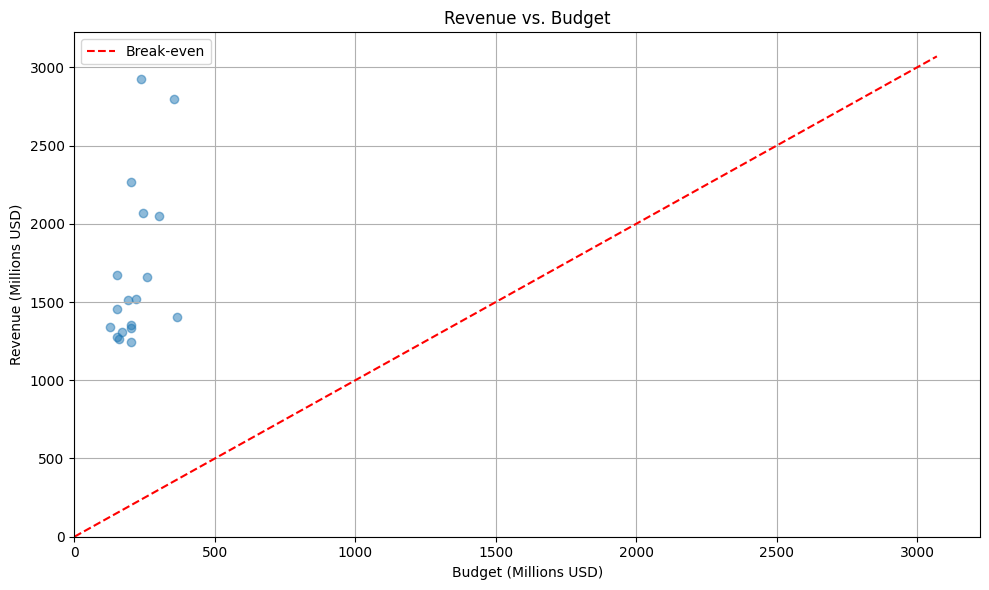

In [161]:
plot_revenue_vs_budget(df_prepared, budget_col, revenue_col)


--- Plotting: ROI Distribution by Genre ---


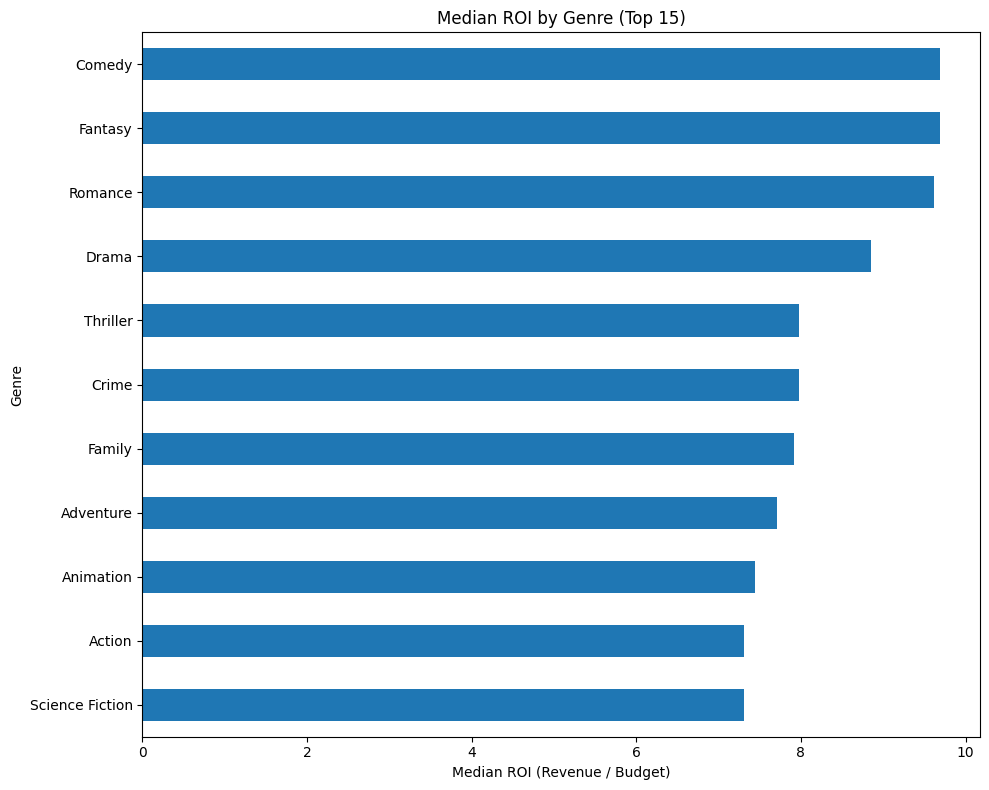

In [162]:
plot_roi_by_genre(df_prepared, budget_col, revenue_col, genre_col)


--- Plotting: Popularity vs. Rating ---


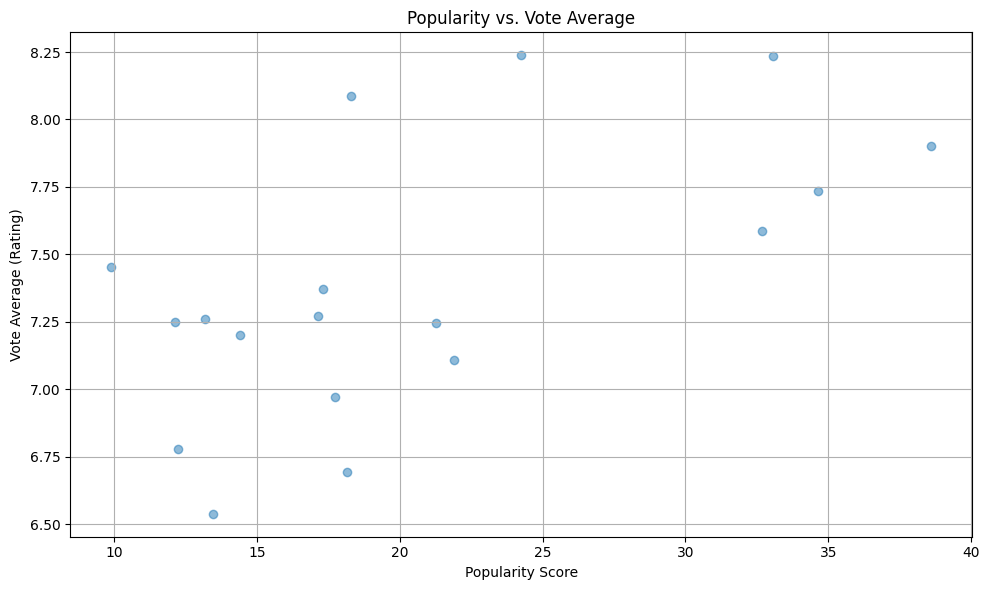

In [163]:
plot_popularity_vs_rating(df_prepared, popularity_col, rating_col)